###How to run the file?
Before running the notebook, create a shortcut to the shared Google Drive folder containing the dataset (following link: https://drive.google.com/drive/folders/1EWzKlZ5VmYJkBvbdPm5rCyl28jE8HH6M?usp=drive_link) and add it to your own Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After mounting Google Drive in Colab, update the os.chdir() path if necessary so that it points to the folder containing the dataset in your MyDrive.

In [ ]:
import os

# Change the current working directory to your specific folder
os.chdir('/content/drive/MyDrive/Group Assignment - A26_I_DTS_DL_03')

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/.shortcut-targets-by-id/1EWzKlZ5VmYJkBvbdPm5rCyl28jE8HH6M/Group Assignment - A26_I_DTS_DL_03


### Unzipping the Dataset

First, we'll unzip the `Banana Ripeness.zip` file. If the file is not in your current working directory, please specify the correct path.

In [ ]:
import os

unzip_dir = 'Banana_Ripeness_Dataset'

# Check if the directory already exists and is not empty
# The original 'unzip -q' overwrites if files are present, so checking for existence is sufficient.
if not os.path.exists(unzip_dir) or not os.listdir(unzip_dir):
    # Re-using existing variables from the previous cell
    zip_file_name = 'Banana Ripeness Classification.v1-original-images.folder.zip'

    # Create a directory for the unzipped content if it doesn't exist
    !mkdir -p "{unzip_dir}"

    # Unzip the content into the new directory
    # The -q flag is for quiet mode (less output)
    # The -d flag specifies the destination directory
    !unzip -q "{zip_file_name}" -d "{unzip_dir}"

    print(f"'{zip_file_name}' unzipped to '{unzip_dir}' successfully.")
else:
    print(f"Dataset already unzipped in '{unzip_dir}'. Skipping unzipping.")


print(f"\nListing contents of '{unzip_dir}':")
!ls -F "{unzip_dir}"

'Banana Ripeness Classification.v1-original-images.folder.zip' unzipped to 'Banana_Ripeness_Dataset' successfully.

Listing contents of 'Banana_Ripeness_Dataset':
README.dataset.txt  README.roboflow.txt  test/	train/	valid/


### Exploring the Dataset Structure

Now, let's examine the directory structure of the unzipped dataset to understand how the images are organized. This will help us in preparing the data for our model.

In [ ]:
import os

# Path to the unzipped dataset directory
dataset_path = './Banana_Ripeness_Dataset'

print(f"Dataset structure within '{dataset_path}':\n")

# Walk through the directory and print its structure
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
#    for f in files:
#        print(f'{subindent}{f}')


Dataset structure within './Banana_Ripeness_Dataset':

Banana_Ripeness_Dataset/
    test/
        freshripe/
        freshunripe/
        overripe/
        ripe/
        rotten/
        unripe/
    train/
        freshripe/
        freshunripe/
        overripe/
        ripe/
        rotten/
        unripe/
    valid/
        freshripe/
        freshunripe/
        overripe/
        ripe/
        rotten/
        unripe/


### Counting Images per Category

To understand the distribution of our dataset, we will count the number of images in each ripeness category across the training, validation, and test sets.

In [ ]:
import os

dataset_base_path = './Banana_Ripeness_Dataset'

def count_images_in_subfolders(base_path):
    counts = {}
    for subset in ['train', 'valid', 'test']:
        subset_path = os.path.join(base_path, subset)
        if os.path.exists(subset_path):
            counts[subset] = {}
            for category_folder in os.listdir(subset_path):
                category_path = os.path.join(subset_path, category_folder)
                if os.path.isdir(category_path):
                    image_files = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
                    counts[subset][category_folder] = len(image_files)
    return counts

image_counts = count_images_in_subfolders(dataset_base_path)

print("Image counts per subset and category:")
for subset, categories in image_counts.items():
    print(f"  {subset.capitalize()}:")
    total_subset_images = 0
    for category, count in categories.items():
        print(f"    {category}: {count} images")
        total_subset_images += count
    print(f"    Total in {subset}: {total_subset_images} images\n")


Image counts per subset and category:
  Train:
    freshripe: 704 images
    freshunripe: 501 images
    overripe: 783 images
    ripe: 470 images
    rotten: 1340 images
    unripe: 133 images
    Total in train: 3931 images

  Valid:
    freshripe: 207 images
    freshunripe: 136 images
    overripe: 229 images
    ripe: 132 images
    rotten: 388 images
    unripe: 31 images
    Total in valid: 1123 images

  Test:
    freshripe: 102 images
    freshunripe: 83 images
    overripe: 113 images
    ripe: 52 images
    rotten: 185 images
    unripe: 27 images
    Total in test: 562 images



### Summary of Dataset Distribution

,folder,counts
0,train,3931
1,valid,1123
2,test,562


,class,counts
0,freshripe,704
1,freshunripe,501
2,overripe,783
3,ripe,470
4,rotten,1340
5,unripe,133
6,freshripe,207
7,freshunripe,136
8,overripe,229
9,ripe,132


,folder,class,counts
0,train,freshripe,704
1,train,freshunripe,501
2,train,overripe,783
3,train,ripe,470
4,train,rotten,1340
5,train,unripe,133
6,valid,freshripe,207
7,valid,freshunripe,136
8,valid,overripe,229
9,valid,ripe,132


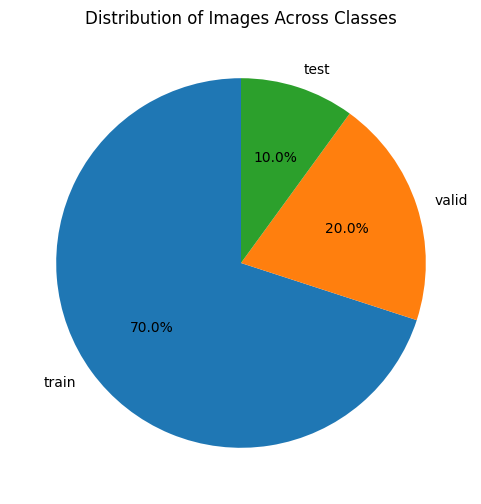

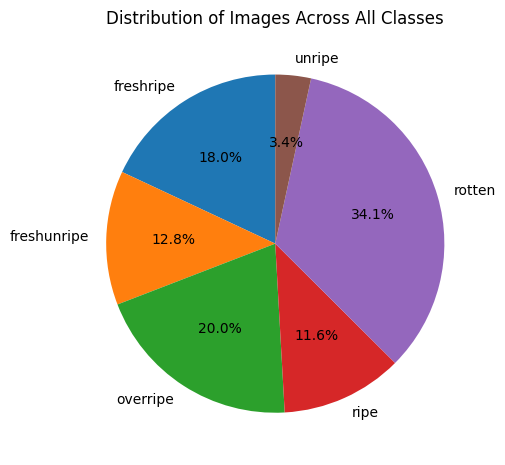

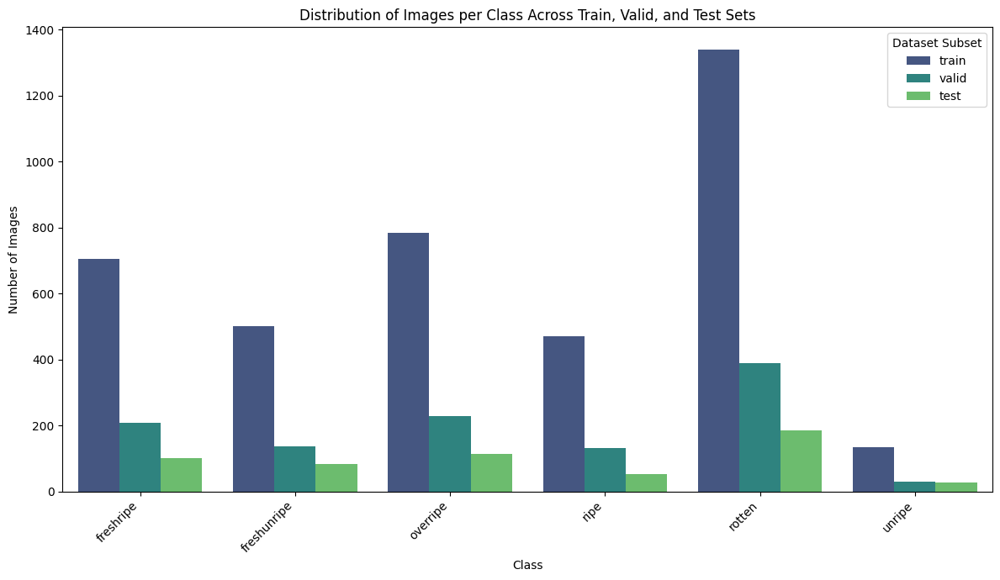

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for pie chart (subset vs total)
plot_data = []

for subset, categories in image_counts.items():
    plot_data.append({'folder': subset, 'counts': sum(categories.values())})

df_pie = pd.DataFrame(plot_data)
display(df_pie)

# Create the pie chart

plt.figure(figsize=(6, 6))
plt.pie(df_pie['counts'], labels=df_pie['folder'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Images Across Classes')

# Prepare data for pie chart (class vs total)
plot_data = []
for subset, categories in image_counts.items():
    for category, count in categories.items():
        plot_data.append({'class': category, 'counts': count})

df_pie_class = pd.DataFrame(plot_data)
display(df_pie_class)

#Create the pie chart

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# Corrected labels: Use the index of the grouped data for labels
class_sums = df_pie_class.groupby('class')['counts'].sum()
plt.pie(class_sums, labels=class_sums.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Images Across All Classes') # Changed title to be more accurate

# Prepare data for bar plot
barplot_data = []
for subset, categories in image_counts.items():
    for category, count in categories.items():
        barplot_data.append({'folder': subset, 'class': category, 'counts': count})

df_counts = pd.DataFrame(barplot_data)
display(df_counts)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(data=df_counts, x='class', y='counts', hue='folder', palette='viridis')
plt.title('Distribution of Images per Class Across Train, Valid, and Test Sets')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset Subset')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Calculate percentages for each class within each subset
percentage_data = []
for subset, categories in image_counts.items():
    total_images_in_subset = sum(categories.values())
    for category, count in categories.items():
        percentage = (count / total_images_in_subset) * 100 if total_images_in_subset > 0 else 0
        percentage_data.append({'folder': subset, 'class': category, 'counts': count, 'percentage': percentage})

df_percentages = pd.DataFrame(percentage_data)
display(df_percentages)


,folder,class,counts,percentage
0,train,freshripe,704,17.908929
1,train,freshunripe,501,12.744849
2,train,overripe,783,19.918596
3,train,ripe,470,11.956245
4,train,rotten,1340,34.088018
5,train,unripe,133,3.383363
6,valid,freshripe,207,18.432769
7,valid,freshunripe,136,12.110419
8,valid,overripe,229,20.391808
9,valid,ripe,132,11.754230


### Interactive Class Distribution Analysis

Use the dropdown menus below to explore the percentage distribution of classes by selecting a specific subset or class. This allows for a more focused analysis of the dataset's composition.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique subsets and classes
all_subsets = ['All'] + sorted(df_percentages['folder'].unique().tolist())
all_classes = ['All'] + sorted(df_percentages['class'].unique().tolist())

# Create dropdown widgets
subset_dropdown = widgets.Dropdown(
    options=all_subsets,
    value='All',
    description='Select Subset:',
    disabled=False,
)

class_dropdown = widgets.Dropdown(
    options=all_classes,
    value='All',
    description='Select Class:',
    disabled=False,
)

# Define the interactive plotting function
def interactive_plot(subset_selection, class_selection):
    clear_output(wait=True)
    filtered_df = df_percentages.copy()

    if subset_selection != 'All':
        filtered_df = filtered_df[filtered_df['folder'] == subset_selection]
    if class_selection != 'All':
        filtered_df = filtered_df[filtered_df['class'] == class_selection]

    if filtered_df.empty:
        print("No data to display for the selected filters.")
        return

    # Sort data by percentage in descending order for plotting
    filtered_df = filtered_df.sort_values(by='percentage', ascending=False)

    plt.figure(figsize=(10, 6))
    if subset_selection == 'All' and class_selection == 'All':
        # Original plot for overall distribution
        ax = sns.barplot(data=filtered_df, x='class', y='percentage', hue='folder', palette='viridis') # Using 'viridis' for sequential
        plt.title('Overall Percentage Distribution of Classes Across Subsets')
    elif subset_selection != 'All' and class_selection == 'All':
        # Distribution within a selected subset
        ax = sns.barplot(data=filtered_df, x='class', y='percentage', palette='viridis_r') # _r reverses the colormap, so darker means more
        plt.title(f'Percentage Distribution of Classes within {subset_selection.capitalize()} Set')
    elif subset_selection == 'All' and class_selection != 'All':
        # Distribution of a single class across subsets
        ax = sns.barplot(data=filtered_df, x='folder', y='percentage', palette='viridis_r')
        plt.title(f'Percentage of "{class_selection}" Class Across Subsets')
    else:
        # Specific subset and specific class
        ax = sns.barplot(data=filtered_df, x='class', y='percentage', hue='folder', palette='viridis')
        plt.title(f'Percentage of "{class_selection}" in {subset_selection.capitalize()} Set')

    plt.xlabel('Class' if class_selection == 'All' else ( 'Subset' if subset_selection == 'All' else 'Class'))
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')

    # Add percentage labels on top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

    # Adjust y-axis limit to fit labels, ensuring it doesn't go below 0
    max_perc = filtered_df['percentage'].max()
    if max_perc > 0:
        plt.ylim(0, max_perc * 1.2) # Give a bit more space for labels
    else:
        plt.ylim(0, 10) # Default small range if max is 0

    plt.tight_layout()
    plt.show()

# Display the interactive widget
interactive_widget = widgets.interactive(interactive_plot, subset_selection=subset_dropdown, class_selection=class_dropdown)
display(interactive_widget)


interactive(children=(Dropdown(description='Select Subset:', options=('All', 'test', 'train', 'valid'), value=…

### Descriptive Analysis of Class Imbalance

Based on the image counts and percentage distributions across the training, validation, and test datasets, the following class imbalance observations have been identified:

*   **Overall Imbalance:** The dataset exhibits a significant class imbalance across all splits. The 'rotten' class consistently represents the largest proportion of images, while the 'unripe' class is notably the smallest.

*   **Training Set:**
    *   'rotten': ~34.1%
    *   'overripe': ~19.9%
    *   'freshripe': ~17.9%
    *   'freshunripe': ~12.7%
    *   'ripe': ~12.0%
    *   'unripe': ~3.4%
    The training set shows 'rotten' as the most prevalent class, being approximately 10 times larger than the 'unripe' class. This imbalance could lead to models biased towards classifying images as 'rotten' and potentially underperforming on 'unripe' images.

*   **Validation Set:**
    *   'rotten': ~34.5%
    *   'overripe': ~20.4%
    *   'freshripe': ~18.4%
    *   'freshunripe': ~12.1%
    *   'ripe': ~11.8%
    *   'unripe': ~2.8%
    The validation set mirrors the training set's imbalance, with 'rotten' remaining the dominant class and 'unripe' being critically underrepresented. This consistent distribution helps ensure that the validation performance is a realistic indicator of the model's behavior on similar imbalanced data.

*   **Test Set:**
    *   'rotten': ~32.9%
    *   'overripe': ~20.1%
    *   'freshripe': ~18.1%
    *   'freshunripe': ~14.8%
    *   'ripe': ~9.3%
    *   'unripe': ~4.8%
    The test set also demonstrates a similar class distribution, though 'unripe' shows a slightly higher percentage compared to the training and validation sets, it remains significantly smaller than 'rotten'. Evaluating on this set will confirm how well the model generalizes to unseen data with comparable class frequencies.

**Implications for Model Training:**

The observed severe class imbalance, particularly the disproportionately high number of 'rotten' images and very low number of 'unripe' images, suggests that a standard training approach might result in a model that performs poorly on minority classes. Strategies such as data augmentation (especially for minority classes), oversampling minority classes, undersampling majority classes, using weighted loss functions, or employing techniques like SMOTE (Synthetic Minority Over-sampling Technique) should be considered during model development to mitigate this issue and improve generalization across all ripeness stages.

### Visualizing Representative Images per Class

To further understand the dataset, let's visualize a sample image from each class within the training, validation, and test subsets. This provides a qualitative view of the different ripeness stages and how they appear in the dataset.

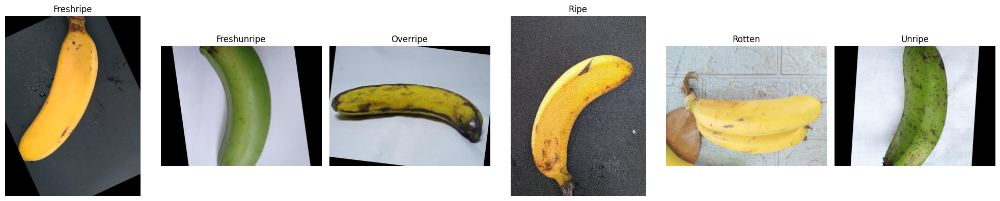

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_base_path = './Banana_Ripeness_Dataset'
# Changed to only process the 'train' subset as requested by 'just using one subset'
subsets_to_display = ['train']
classes = sorted(df_percentages['class'].unique().tolist()) # Use existing classes from df_percentages

# Adjust figure size for a single row of plots
plt.figure(figsize=(20, 4)) # Adjusted height for better visualization of a single row

plot_idx = 1

for subset in subsets_to_display: # Loop only through the selected subset
    for cls in classes:
        class_path = os.path.join(dataset_base_path, subset, cls)
        if os.path.exists(class_path) and os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if image_files:
                # Take the first image found in the directory
                image_path = os.path.join(class_path, image_files[0])
                try:
                    img = Image.open(image_path)
                    # Subplot dimensions: 1 row, len(classes) columns
                    plt.subplot(1, len(classes), plot_idx)
                    plt.imshow(img)
                    # Title only needs to show the class, as subset is fixed (e.g., 'train')
                    plt.title(f"{cls.capitalize()}")
                    plt.axis('off') # Hide axes for cleaner image display
                    plot_idx += 1
                except Exception as e:
                    print(f"Could not load image {image_path}: {e}")
            else:
                print(f"No images found in {class_path}")
        else:
            print(f"Directory not found: {class_path}")

plt.tight_layout()
plt.show()

### Representative Images and Descriptions (from 'train' subset)

Below, you'll find a single representative image for each banana ripeness class from the training set, followed by its detailed description. This organization aims to make it easier to connect each image with its corresponding explanation.

#### Freshripe

**Description:** These bananas typically have a bright yellow peel, often with some green remaining at the tips. They are firm to the touch and have a sweet taste with a slight tang. There are usually no brown spots or blemishes, indicating peak freshness and ripeness for consumption.

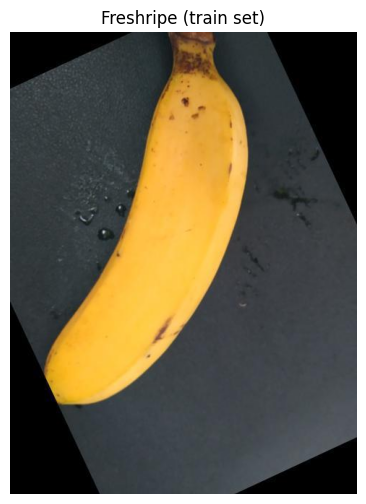

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_base_path = './Banana_Ripeness_Dataset'
subset = 'train'
cls = 'freshripe'

class_path = os.path.join(dataset_base_path, subset, cls)
image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    image_path = os.path.join(class_path, image_files[0])
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{cls.capitalize()} ({subset} set)")
    plt.axis('off')
    plt.show()
else:
    print(f"No images found for {cls} in {subset} subset.")

#### Freshunripe

**Description:** Bananas in this category are predominantly green in color, indicating they are not yet ripe. They are very firm and starchy, with a less sweet flavor. These bananas are often chosen for cooking or if one prefers a firmer texture.

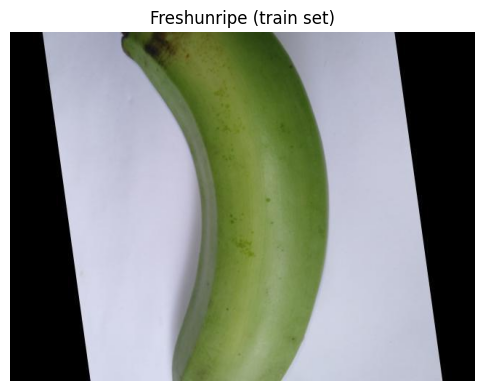

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_base_path = './Banana_Ripeness_Dataset'
subset = 'train'
cls = 'freshunripe'

class_path = os.path.join(dataset_base_path, subset, cls)
image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    image_path = os.path.join(class_path, image_files[0])
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{cls.capitalize()} ({subset} set)")
    plt.axis('off')
    plt.show()
else:
    print(f"No images found for {cls} in {subset} subset.")

#### Overripe

**Description:** Overripe bananas are characterized by a yellow peel extensively covered with brown or black spots, or even entirely black. The flesh is very soft, sweet, and often mushy. While not ideal for eating raw, they are excellent for baking or smoothies due to their high sugar content and soft texture.

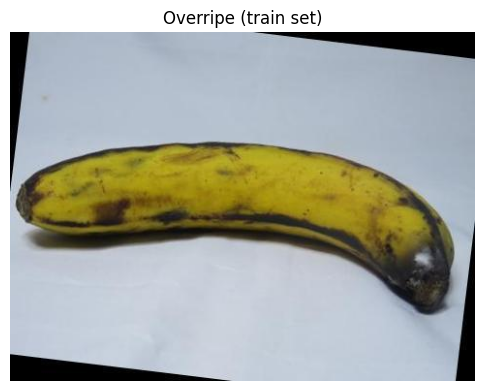

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_base_path = './Banana_Ripeness_Dataset'
subset = 'train'
cls = 'overripe'

class_path = os.path.join(dataset_base_path, subset, cls)
image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    image_path = os.path.join(class_path, image_files[0])
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{cls.capitalize()} ({subset} set)")
    plt.axis('off')
    plt.show()
else:
    print(f"No images found for {cls} in {subset} subset.")

#### Ripe

**Description:** Ripe bananas have a vibrant yellow peel, usually with a few scattered brown speckles. They are slightly soft, easy to peel, and sweet. This is generally considered the optimal stage for eating raw, offering a good balance of flavor and texture.

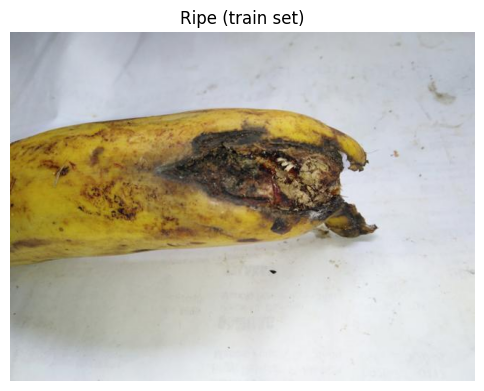

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_base_path = './Banana_Ripeness_Dataset'
subset = 'train'
cls = 'ripe'

class_path = os.path.join(dataset_base_path, subset, cls)
image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    image_path = os.path.join(class_path, image_files[0])
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{cls.capitalize()} ({subset} set)")
    plt.axis('off')
    plt.show()
else:
    print(f"No images found for {cls} in {subset} subset.")

#### Rotten

**Description:** Rotten bananas exhibit significant decay. Their peels are typically completely black, often with signs of mold or decomposition. The flesh is very soft, liquefied, and emits a strong, fermented odor. These are usually past the point of consumption and should be discarded.

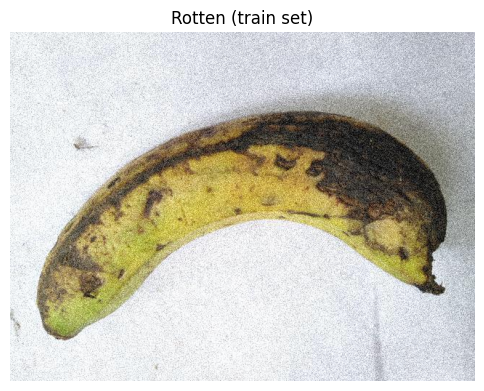

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_base_path = './Banana_Ripeness_Dataset'
subset = 'train'
cls = 'rotten'

class_path = os.path.join(dataset_base_path, subset, cls)
image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    # Attempt to use a different image for 'rotten' to address feedback
    image_index = 0
    if len(image_files) > 1:
        image_index = 1  # Try the second image if available

    image_path = os.path.join(class_path, image_files[image_index])
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{cls.capitalize()} ({subset} set)")
    plt.axis('off')
    plt.show()
else:
    print(f"No images found for {cls} in {subset} subset.")

#### Unripe

**Description:** Similar to 'freshunripe', these bananas are green and very firm. However, they might be even harder and less developed than 'freshunripe', with a strong starchy taste and sometimes a bitter undertone. They require more time to ripen fully.

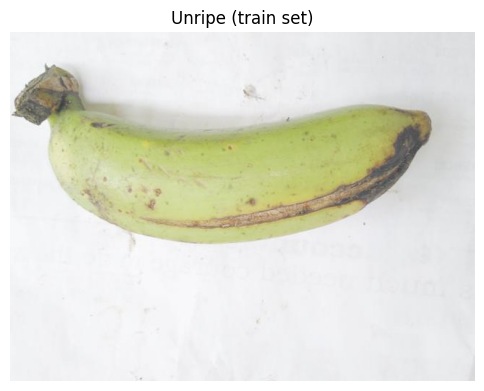

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_base_path = './Banana_Ripeness_Dataset'
subset = 'train'
cls = 'unripe'

class_path = os.path.join(dataset_base_path, subset, cls)
image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    image_path = os.path.join(class_path, image_files[0])
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{cls.capitalize()} ({subset} set)")
    plt.axis('off')
    plt.show()
else:
    print(f"No images found for {cls} in {subset} subset.")

In [ ]:
pass # Placeholder to clear previous image outputs from this cell

## Additional Exploratory Data Analysis

Before defining the Computer Vision model, we further investigate three aspects of the image dataset:

**A. Image dimensions and file formats** — to understand the technical characteristics of the images and determine whether resizing will be necessary.

**B. Visual variability within classes** — to assess how much the appearance of bananas varies within each ripeness class.

**C. Color analysis** — since ripeness is strongly related to peel color, we examine simple color statistics across the classes.

For the visual variability and color analysis, we focus on the **training set**, because these analyses are intended to understand the data that will be used to train the model.

### A. Image Dimensions and File Formats

In [ ]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# Dataset path
dataset_base_path = './Banana_Ripeness_Dataset'

# Supported image extensions
image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.webp')

image_metadata = []

# Inspect all available subsets
for subset in ['train', 'valid', 'test']:
    subset_path = os.path.join(dataset_base_path, subset)

    if not os.path.exists(subset_path):
        continue

    for cls in sorted(os.listdir(subset_path)):
        class_path = os.path.join(subset_path, cls)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            if filename.lower().endswith(image_extensions):
                image_path = os.path.join(class_path, filename)

                try:
                    with Image.open(image_path) as img:
                        width, height = img.size
                        image_metadata.append({
                            'subset': subset,
                            'class': cls,
                            'filename': filename,
                            'width': width,
                            'height': height,
                            'aspect_ratio': width / height,
                            'format': img.format,
                            'mode': img.mode
                        })
                except Exception as e:
                    print(f"Could not read {image_path}: {e}")

df_image_metadata = pd.DataFrame(image_metadata)

print(f"Total images successfully analysed: {len(df_image_metadata):,}")

display(
    df_image_metadata[
        ['subset', 'class', 'width', 'height', 'aspect_ratio', 'format', 'mode']
    ].head(10)
)

print("\nImage formats:")
display(df_image_metadata['format'].value_counts().to_frame('count'))

print("\nColor modes:")
display(df_image_metadata['mode'].value_counts().to_frame('count'))

print("\nResolution statistics:")
display(
    df_image_metadata[['width', 'height', 'aspect_ratio']].describe()
)

Total images successfully analysed: 5,616


,subset,class,width,height,aspect_ratio,format,mode
0,train,freshripe,480,640,0.75,JPEG,RGB
1,train,freshripe,480,640,0.75,JPEG,RGB
2,train,freshripe,480,640,0.75,JPEG,RGB
3,train,freshripe,480,640,0.75,JPEG,RGB
4,train,freshripe,480,640,0.75,JPEG,RGB
5,train,freshripe,480,640,0.75,JPEG,RGB
6,train,freshripe,480,640,0.75,JPEG,RGB
7,train,freshripe,480,640,0.75,JPEG,RGB
8,train,freshripe,480,640,0.75,JPEG,RGB
9,train,freshripe,480,640,0.75,JPEG,RGB



Image formats:


,count
format,
JPEG,5616



Color modes:


,count
mode,
RGB,5616



Resolution statistics:


,width,height,aspect_ratio
count,5616.000000,5616.000000,5616.000000
mean,563.988604,443.034188,1.291578
std,79.907622,79.229928,0.150393
min,480.000000,360.000000,0.750000
25%,480.000000,360.000000,1.333333
50%,640.000000,480.000000,1.333333
75%,640.000000,480.000000,1.333333
max,640.000000,640.000000,1.333333


In [ ]:
import numpy as np
import cv2
import random
import pandas as pd
from PIL import Image
import os

# Number of images sampled per class is not strictly needed if we iterate through df_image_metadata directly
# SAMPLE_SIZE = 50

color_features = []

random.seed(42)

# Iterate through the already gathered metadata (df_image_metadata)
# to ensure consistency with images that were successfully read and to include all subsets.
for index, row in df_image_metadata.iterrows():
    subset = row['subset']
    cls = row['class']
    filename = row['filename']
    # Construct the full path to the image
    image_path = os.path.join(dataset_base_path, subset, cls, filename)

    try:
        # Open and convert image to RGB, then to a numpy array for processing
        img = Image.open(image_path).convert('RGB')
        img_array = np.asarray(img, dtype=np.float32) / 255.0 # Normalize pixel values to [0, 1]

        # Calculate Mean RGB
        mean_rgb = img_array.mean(axis=(0, 1))

        # Convert RGB to HSV using OpenCV for color space analysis
        hsv_array = cv2.cvtColor(
            img_array.astype(np.float32),
            cv2.COLOR_RGB2HSV
        )

        # Normalize Hue to [0, 1] (OpenCV float32 H is 0-360, S,V 0-1)
        hsv_array[:, :, 0] /= 360.0

        # Calculate Mean HSV
        mean_hsv = hsv_array.mean(axis=(0, 1))

        # Append the extracted features to the list
        color_features.append({
            'subset': subset,
            'class': cls,
            'filename': filename,
            'mean_R': mean_rgb[0],
            'mean_G': mean_rgb[1],
            'mean_B': mean_rgb[2],
            'mean_H': mean_hsv[0],
            'mean_S': mean_hsv[1],
            'mean_V': mean_hsv[2]
        })

    except Exception as e:
        # Print errors only for images that were previously identified but now fail to load/process
        # This should be rare if df_image_metadata was constructed from valid images.
        print(f"Could not analyse {image_path}: {e}")

# Create a DataFrame from the collected color features
df_color = pd.DataFrame(color_features)

print(f"Images included in color analysis: {len(df_color):,}")

display(df_color.head())

print("Mean color statistics by class and subset:")

# Group by subset and class to get mean color statistics for all subsets
color_summary_all = (
    df_color
    .groupby(['subset', 'class'])[[
        'mean_R', 'mean_G', 'mean_B',
        'mean_H', 'mean_S', 'mean_V'
    ]]
    .mean()
    .round(3)
)

display(color_summary_all)

Images included in color analysis: 5,616


,subset,class,filename,mean_R,mean_G,mean_B,mean_H,mean_S,mean_V
0,train,freshripe,musa-acuminata-banana-c8e5105b-394a-11ec-9e55-...,0.410173,0.356826,0.265819,0.490042,0.217069,0.420237
1,train,freshripe,musa-acuminata-freshripe-4b1a717a-2653-11ec-99...,0.642425,0.655305,0.499741,0.402976,0.382822,0.688446
2,train,freshripe,musa-acuminata-freshripe-46eeacbf-2653-11ec-b2...,0.672699,0.678626,0.574164,0.467204,0.306038,0.721149
3,train,freshripe,musa-acuminata-banana-f331a7bc-394a-11ec-bbab-...,0.562684,0.575637,0.519596,0.367315,0.395441,0.673303
4,train,freshripe,musa-acuminata-freshripe-7eaf035a-1d0a-11ec-97...,0.471629,0.482405,0.407702,0.351578,0.277074,0.521555


Mean color statistics by class and subset:


mean_R  mean_G  mean_B  mean_H  mean_S  mean_V
subset class                                                      
test   freshripe     0.565   0.556   0.466   0.422   0.300   0.610
       freshunripe   0.663   0.690   0.607   0.420   0.223   0.708
       overripe      0.597   0.598   0.577   0.431   0.181   0.633
       ripe          0.640   0.631   0.587   0.440   0.264   0.693
       rotten        0.640   0.610   0.562   0.414   0.210   0.657
       unripe        0.719   0.739   0.665   0.454   0.205   0.756
train  freshripe     0.562   0.548   0.467   0.433   0.308   0.609
       freshunripe   0.656   0.681   0.601   0.422   0.216   0.699
       overripe      0.596   0.597   0.576   0.435   0.182   0.632
       ripe          0.623   0.618   0.573   0.446   0.273   0.679
       rotten        0.637   0.606   0.551   0.403   0.214   0.653
       unripe        0.702   0.725   0.657   0.453   0.197   0.741
valid  freshripe     0.556   0.548   0.466   0.421   0.300   0.606
       freshunripe   0.669   0.693   0.615   0.426   0.210   0.711
       overripe      0.592   0.593   0.572   0.431   0.184   0.629
       ripe          0.639   0.640   0.587   0.445   0.268   0.696
       rotten        0.626   0.593   0.542   0.406   0.218   0.643
       unripe        0.679   0.700   0.630   0.439   0.200   0.715

width              height              aspect_ratio            
         min    mean  max    min    mean  max          min  mean   max
subset                                                                
test     480  567.69  640    360  444.20  640         0.75  1.29  1.33
train    480  563.72  640    360  442.95  640         0.75  1.29  1.33
valid    480  563.06  640    360  442.74  640         0.75  1.29  1.33

Most common image dimensions:


,width,height,count
2,640,480,2948
0,480,360,2266
1,480,640,402


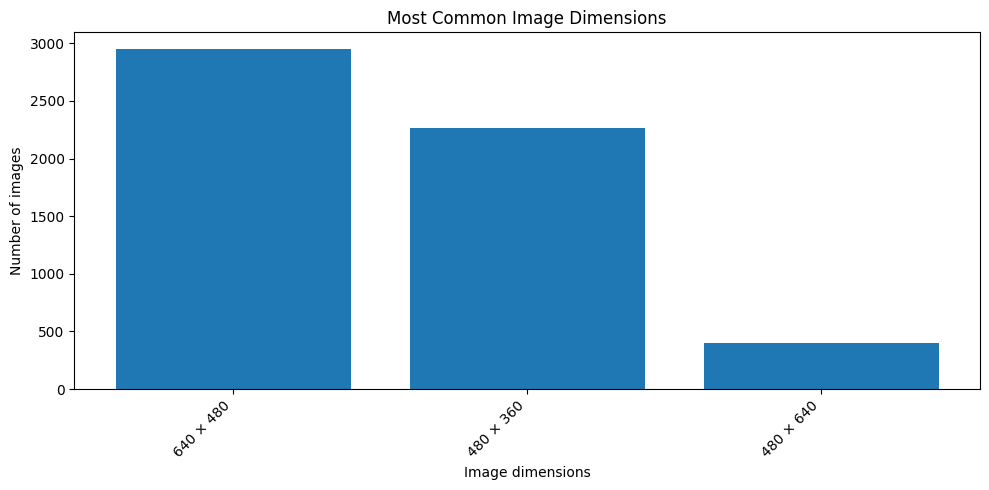

In [ ]:
# Resolution distribution by subset
resolution_summary = (
    df_image_metadata
    .groupby('subset')[['width', 'height', 'aspect_ratio']]
    .agg(['min', 'mean', 'max'])
    .round(2)
)

display(resolution_summary)

# Most common image dimensions
dimension_counts = (
    df_image_metadata
    .groupby(['width', 'height'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print("Most common image dimensions:")
display(dimension_counts.head(10))

# Visualize the most common image dimensions
top_dimensions = dimension_counts.head(10).copy()
top_dimensions['dimension'] = (
    top_dimensions['width'].astype(str)
    + ' × '
    + top_dimensions['height'].astype(str)
)

plt.figure(figsize=(10, 5))
plt.bar(top_dimensions['dimension'], top_dimensions['count'])
plt.title('Most Common Image Dimensions')
plt.xlabel('Image dimensions')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** this analysis allows us to determine whether the dataset contains images with different resolutions or aspect ratios. If substantial variation is present, a common input size will be required before training the CNN.

### B. Visual Variability Within Classes

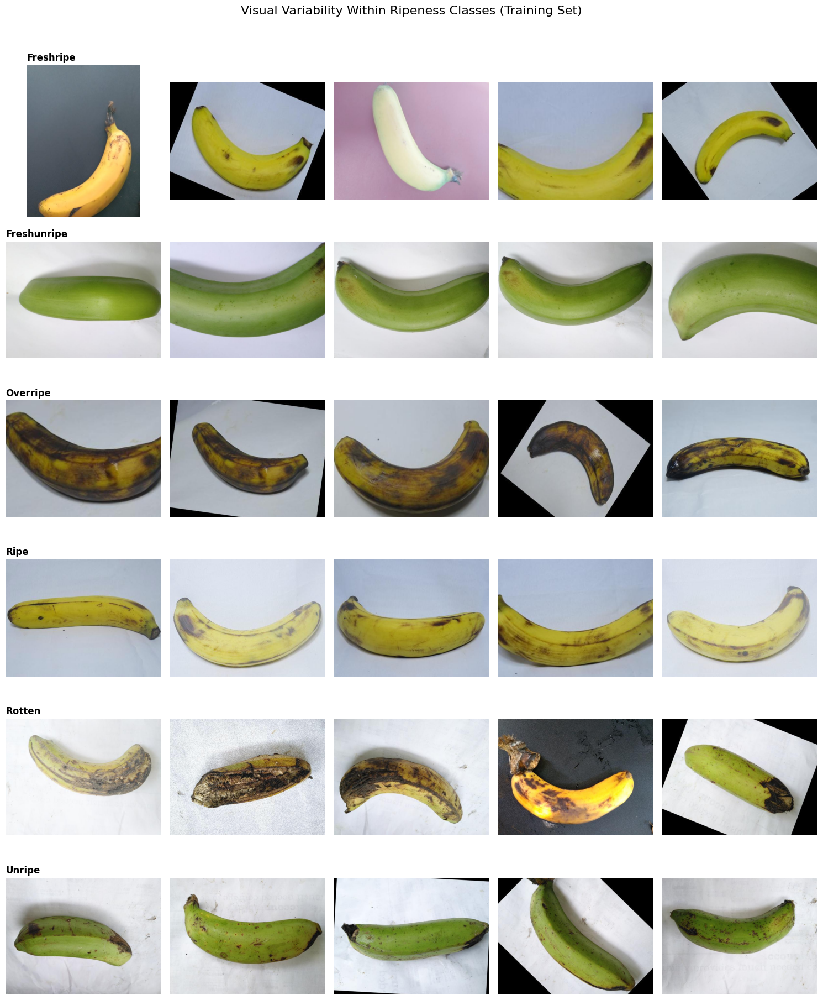

In [ ]:
import random
import math
from PIL import Image

# We use only the training set for this qualitative analysis
subset = 'train'

# Read classes directly from the training directory
train_path = os.path.join(dataset_base_path, subset)
classes = sorted([
    cls for cls in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, cls))
])

# Number of examples shown for each class
images_per_class = 5

fig, axes = plt.subplots(
    len(classes),
    images_per_class,
    figsize=(15, 3 * len(classes))
)

# Make axes consistently 2-dimensional
if len(classes) == 1:
    axes = [axes]

for row, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    # Random sample, reproducible across runs
    random.seed(42)
    sample_size = min(images_per_class, len(image_files))
    selected_files = random.sample(image_files, sample_size)

    for col in range(images_per_class):
        ax = axes[row][col]

        if col < sample_size:
            image_path = os.path.join(class_path, selected_files[col])

            try:
                img = Image.open(image_path)
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
                print(f"Could not load {image_path}: {e}")
        else:
            ax.axis('off')

        ax.axis('off')

        if col == 0:
            ax.set_title(cls.capitalize(), loc='left', fontweight='bold')

plt.suptitle(
    'Visual Variability Within Ripeness Classes (Training Set)',
    fontsize=16,
    y=1.02
)
plt.tight_layout()
plt.show()

When examining the grid, focus on:

- differences in banana orientation and position;
- differences in scale and cropping;
- lighting and background variations;
- differences in peel color;
- spots, bruises and other texture patterns;
- similarities between neighbouring ripeness stages.

This provides a qualitative indication of how difficult the classification problem may be and which visual characteristics a CNN may need to learn.

### C. Color Analysis

In [ ]:
import numpy as np
import cv2
import random
import pandas as pd
from PIL import Image
import os

# Number of images sampled per class is not strictly needed if we iterate through df_image_metadata directly
# SAMPLE_SIZE = 50

color_features = []

random.seed(42)

# Iterate through the already gathered metadata (df_image_metadata)
# to ensure consistency with images that were successfully read and to include all subsets.
for index, row in df_image_metadata.iterrows():
    subset = row['subset']
    cls = row['class']
    filename = row['filename']
    # Construct the full path to the image
    image_path = os.path.join(dataset_base_path, subset, cls, filename)

    try:
        # Open and convert image to RGB, then to a numpy array for processing
        img = Image.open(image_path).convert('RGB')
        img_array = np.asarray(img, dtype=np.float32) / 255.0 # Normalize pixel values to [0, 1]

        # Calculate Mean RGB
        mean_rgb = img_array.mean(axis=(0, 1))

        # Convert RGB to HSV using OpenCV for color space analysis
        hsv_array = cv2.cvtColor(
            img_array.astype(np.float32),
            cv2.COLOR_RGB2HSV
        )

        # Normalize Hue to [0, 1] (OpenCV float32 H is 0-360, S,V 0-1)
        hsv_array[:, :, 0] /= 360.0

        # Calculate Mean HSV
        mean_hsv = hsv_array.mean(axis=(0, 1))

        # Append the extracted features to the list
        color_features.append({
            'subset': subset,
            'class': cls,
            'filename': filename,
            'mean_R': mean_rgb[0],
            'mean_G': mean_rgb[1],
            'mean_B': mean_rgb[2],
            'mean_H': mean_hsv[0],
            'mean_S': mean_hsv[1],
            'mean_V': mean_hsv[2]
        })

    except Exception as e:
        # Print errors only for images that were previously identified but now fail to load/process
        # This should be rare if df_image_metadata was constructed from valid images.
        print(f"Could not analyse {image_path}: {e}")

# Create a DataFrame from the collected color features
df_color = pd.DataFrame(color_features)

print(f"Images included in color analysis: {len(df_color):,}")

display(df_color.head())

print("Mean color statistics by class and subset:")

# Group by subset and class to get mean color statistics for all subsets
color_summary_all = (
    df_color
    .groupby(['subset', 'class'])[[
        'mean_R', 'mean_G', 'mean_B',
        'mean_H', 'mean_S', 'mean_V'
    ]]
    .mean()
    .round(3)
)

display(color_summary_all)

Images included in color analysis: 5,616


,subset,class,filename,mean_R,mean_G,mean_B,mean_H,mean_S,mean_V
0,train,freshripe,musa-acuminata-banana-c8e5105b-394a-11ec-9e55-...,0.410173,0.356826,0.265819,0.490042,0.217069,0.420237
1,train,freshripe,musa-acuminata-freshripe-4b1a717a-2653-11ec-99...,0.642425,0.655305,0.499741,0.402976,0.382822,0.688446
2,train,freshripe,musa-acuminata-freshripe-46eeacbf-2653-11ec-b2...,0.672699,0.678626,0.574164,0.467204,0.306038,0.721149
3,train,freshripe,musa-acuminata-banana-f331a7bc-394a-11ec-bbab-...,0.562684,0.575637,0.519596,0.367315,0.395441,0.673303
4,train,freshripe,musa-acuminata-freshripe-7eaf035a-1d0a-11ec-97...,0.471629,0.482405,0.407702,0.351578,0.277074,0.521555


Mean color statistics by class and subset:


mean_R  mean_G  mean_B  mean_H  mean_S  mean_V
subset class                                                      
test   freshripe     0.565   0.556   0.466   0.422   0.300   0.610
       freshunripe   0.663   0.690   0.607   0.420   0.223   0.708
       overripe      0.597   0.598   0.577   0.431   0.181   0.633
       ripe          0.640   0.631   0.587   0.440   0.264   0.693
       rotten        0.640   0.610   0.562   0.414   0.210   0.657
       unripe        0.719   0.739   0.665   0.454   0.205   0.756
train  freshripe     0.562   0.548   0.467   0.433   0.308   0.609
       freshunripe   0.656   0.681   0.601   0.422   0.216   0.699
       overripe      0.596   0.597   0.576   0.435   0.182   0.632
       ripe          0.623   0.618   0.573   0.446   0.273   0.679
       rotten        0.637   0.606   0.551   0.403   0.214   0.653
       unripe        0.702   0.725   0.657   0.453   0.197   0.741
valid  freshripe     0.556   0.548   0.466   0.421   0.300   0.606
       freshunripe   0.669   0.693   0.615   0.426   0.210   0.711
       overripe      0.592   0.593   0.572   0.431   0.184   0.629
       ripe          0.639   0.640   0.587   0.445   0.268   0.696
       rotten        0.626   0.593   0.542   0.406   0.218   0.643
       unripe        0.679   0.700   0.630   0.439   0.200   0.715

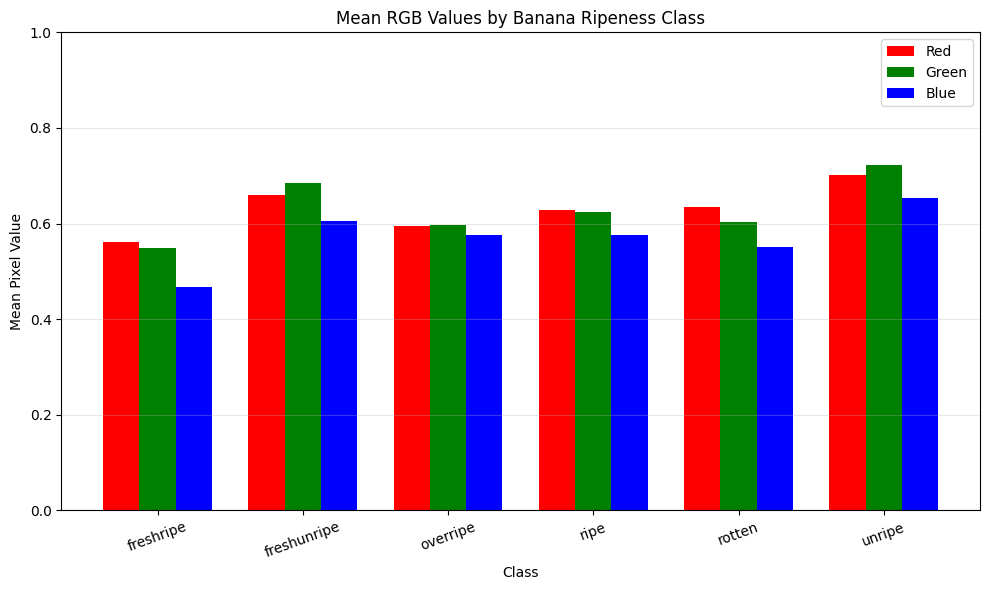

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Mean RGB values by class
rgb_summary = (
    df_color
    .groupby('class')[['mean_R', 'mean_G', 'mean_B']]
    .mean()
    .reindex(classes)
)

x = np.arange(len(rgb_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width,
    rgb_summary['mean_R'],
    width,
    label='Red',
    color='red'
)

ax.bar(
    x,
    rgb_summary['mean_G'],
    width,
    label='Green',
    color='green'
)

ax.bar(
    x + width,
    rgb_summary['mean_B'],
    width,
    label='Blue',
    color='blue'
)

ax.set_title('Mean RGB Values by Banana Ripeness Class')
ax.set_xlabel('Class')
ax.set_ylabel('Mean Pixel Value')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=20)
ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

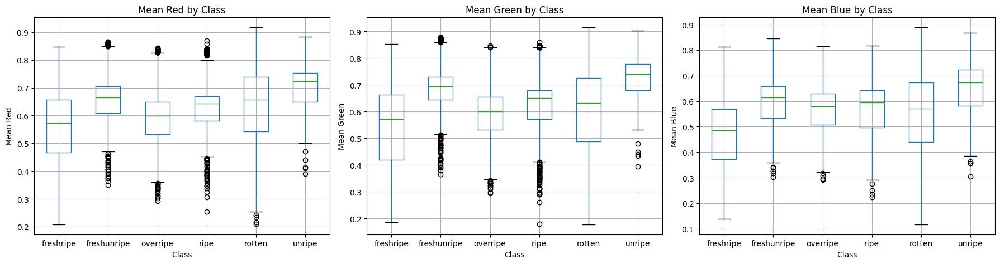

In [ ]:
import matplotlib.pyplot as plt

# Visualize RGB distributions by class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_color.boxplot(
    column='mean_R',
    by='class',
    ax=axes[0]
)
axes[0].set_title('Mean Red by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Red')

df_color.boxplot(
    column='mean_G',
    by='class',
    ax=axes[1]
)
axes[1].set_title('Mean Green by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Mean Green')

df_color.boxplot(
    column='mean_B',
    by='class',
    ax=axes[2]
)
axes[2].set_title('Mean Blue by Class')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Mean Blue')

plt.suptitle('')
plt.tight_layout()
plt.show()

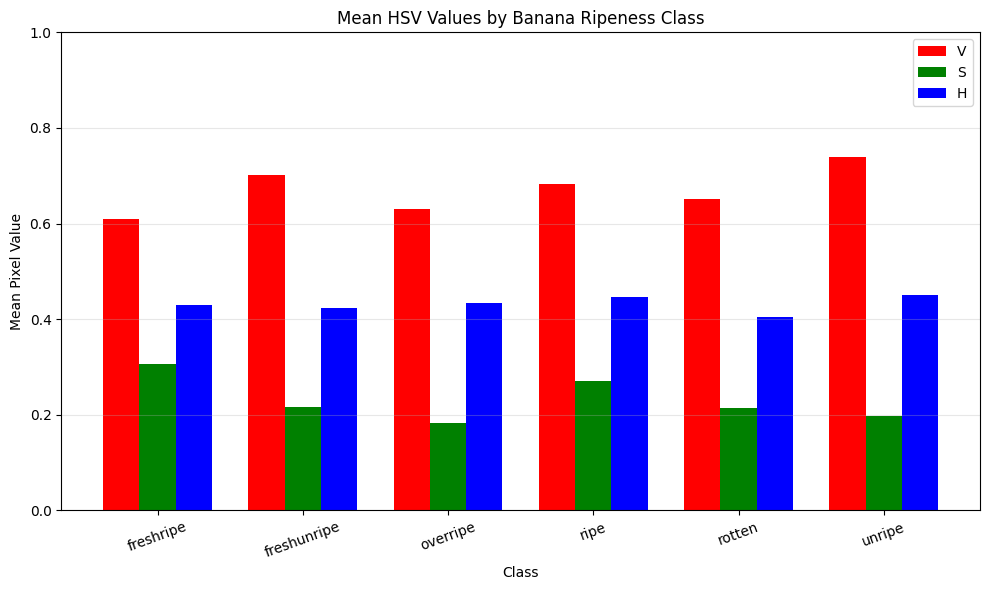

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Mean RGB values by class
rgb_summary = (
    df_color
    .groupby('class')[['mean_V', 'mean_S', 'mean_H']]
    .mean()
    .reindex(classes)
)

x = np.arange(len(rgb_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width,
    rgb_summary['mean_V'],
    width,
    label='V',
    color='red'
)

ax.bar(
    x,
    rgb_summary['mean_S'],
    width,
    label='S',
    color='green'
)

ax.bar(
    x + width,
    rgb_summary['mean_H'],
    width,
    label='H',
    color='blue'
)

ax.set_title('Mean HSV Values by Banana Ripeness Class')
ax.set_xlabel('Class')
ax.set_ylabel('Mean Pixel Value')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=20)
ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

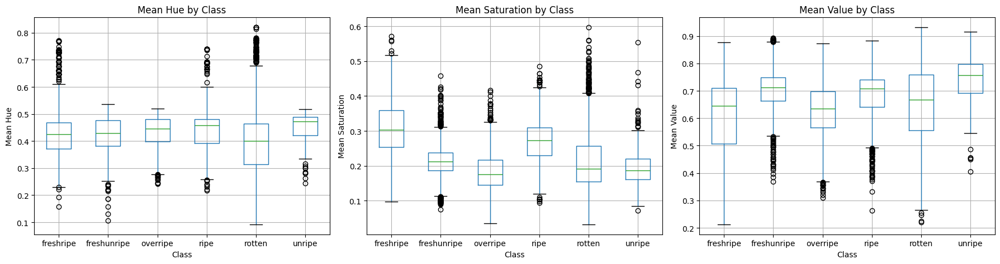

In [ ]:
import matplotlib.pyplot as plt

# Visualize HSV distributions by class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_color.boxplot(
    column='mean_H',
    by='class',
    ax=axes[0]
)
axes[0].set_title('Mean Hue by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Hue')

df_color.boxplot(
    column='mean_S',
    by='class',
    ax=axes[1]
)
axes[1].set_title('Mean Saturation by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Mean Saturation')

df_color.boxplot(
    column='mean_V',
    by='class',
    ax=axes[2]
)
axes[2].set_title('Mean Value by Class')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Mean Value')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Interpretation of the Color Analysis

The color analysis is not intended to replace the CNN with manually engineered color features. Instead, it provides an initial hypothesis about the visual information available in the images.

If the classes show different distributions of **Hue, Saturation or Brightness**, color may represent an important visual cue for classification. However, the CNN will also be able to learn other characteristics such as shapes, edges, texture and dark spots.

The next step is therefore to use these observations to define a **simple CNN architecture** and evaluate whether the visual patterns identified during the EDA are actually useful for distinguishing the five classes.

## Check for GPU availability

In [ ]:
import tensorflow as tf

# Check for GPU availability
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print("GPU is available. Details:")
    for gpu in gpu_available:
        print(f"  Name: {gpu.name}, Type: {gpu.device_type}")
else:
    print("No GPU devices found. Running on CPU.")

No GPU devices found. Running on CPU.


## Logistic Regression Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Prepare the data for logistic regression
X = df_color[['mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V']]
y = df_color['class']

# Encode target labels to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets based on the 'subset' column
X_train = df_color[df_color['subset'] == 'train'][['mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V']]
y_train = df_color[df_color['subset'] == 'train']['class']

X_valid = df_color[df_color['subset'] == 'valid'][['mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V']]
y_valid = df_color[df_color['subset'] == 'valid']['class']

X_test = df_color[df_color['subset'] == 'test'][['mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_S', 'mean_V']]
y_test = df_color[df_color['subset'] == 'test']['class']

# Encode target labels for each split
y_train_encoded = label_encoder.transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)
y_test_encoded = label_encoder.transform(y_test)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_valid)}")
print(f"Test set size: {len(X_test)}")

# Initialize and train Logistic Regression model
# Set max_iter for convergence and solver for multi-class classification
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
log_reg.fit(X_train, y_train_encoded)

print("\nLogistic Regression Model Trained.")

Training set size: 3931
Validation set size: 1123
Test set size: 562


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Model Trained.


## Model Evaluation

Validation Accuracy: 0.5343

Validation Classification Report:
              precision    recall  f1-score   support

   freshripe       0.49      0.51      0.50       207
 freshunripe       0.25      0.01      0.01       136
    overripe       0.60      0.63      0.61       229
        ripe       0.72      0.25      0.37       132
      rotten       0.51      0.82      0.63       388
      unripe       0.00      0.00      0.00        31

    accuracy                           0.53      1123
   macro avg       0.43      0.37      0.35      1123
weighted avg       0.50      0.53      0.48      1123



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


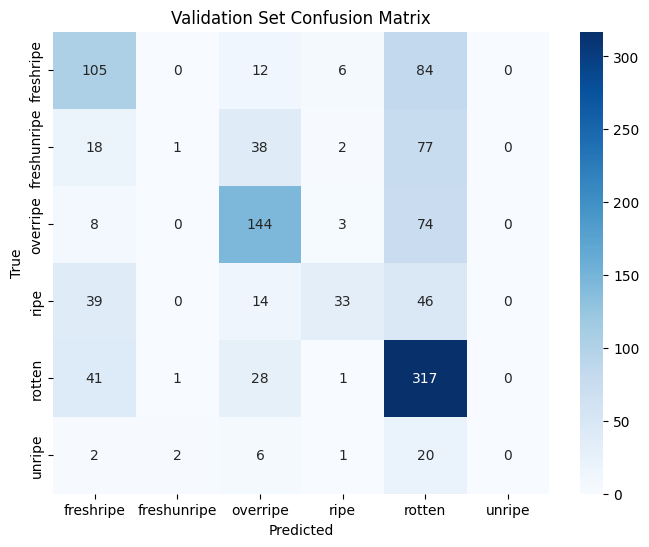


Test Accuracy: 0.5196

Test Classification Report:
              precision    recall  f1-score   support

   freshripe       0.54      0.62      0.58       102
 freshunripe       0.14      0.01      0.02        83
    overripe       0.55      0.58      0.56       113
        ripe       0.71      0.19      0.30        52
      rotten       0.50      0.83      0.62       185
      unripe       0.00      0.00      0.00        27

    accuracy                           0.52       562
   macro avg       0.41      0.37      0.35       562
weighted avg       0.46      0.52      0.45       562



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


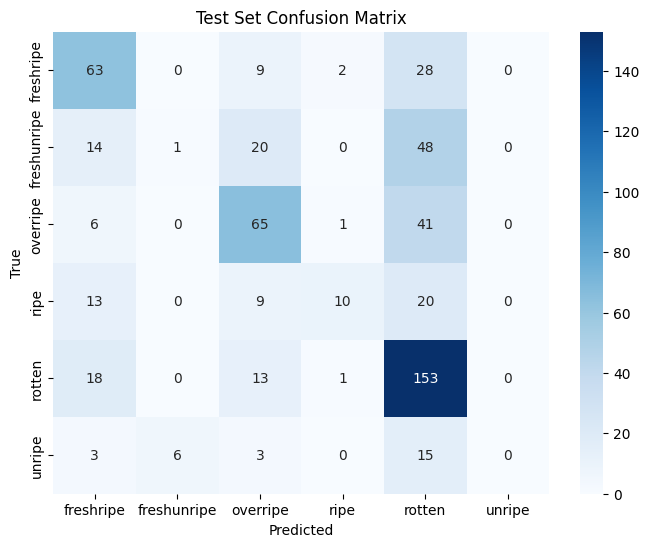

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Evaluate the model on the validation set
y_pred_valid = log_reg.predict(X_valid)
accuracy_valid = accuracy_score(y_valid_encoded, y_pred_valid)
print(f"Validation Accuracy: {accuracy_valid:.4f}")

print("\nValidation Classification Report:")
print(classification_report(y_valid_encoded, y_pred_valid, target_names=label_encoder.classes_))

# Confusion Matrix for Validation Set
cm_valid = confusion_matrix(y_valid_encoded, y_pred_valid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Validation Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Evaluate the model on the test set
y_pred_test = log_reg.predict(X_test)
accuracy_test = accuracy_score(y_test_encoded, y_pred_test)
print(f"\nTest Accuracy: {accuracy_test:.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test_encoded, y_pred_test, target_names=label_encoder.classes_))

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test_encoded, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## AUC-ROC Curves

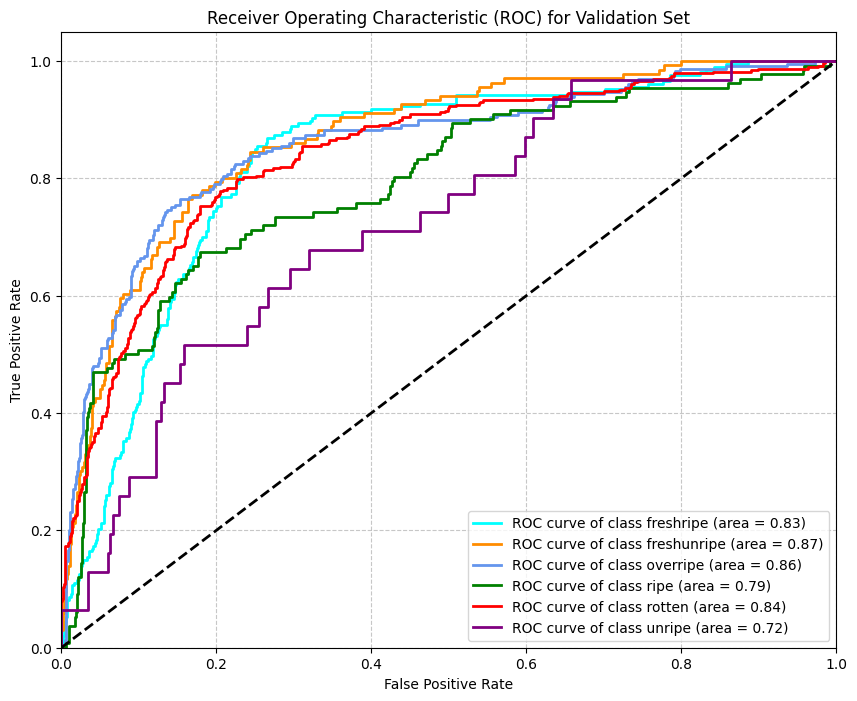

In [ ]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Get predicted probabilities for the validation set
y_prob_valid = log_reg.predict_proba(X_valid)

# Binarize the true labels for ROC curve calculation
n_classes = len(label_encoder.classes_)
y_valid_onehot = pd.get_dummies(y_valid_encoded).values

# Compute ROC curve and AUC for each class on the validation set
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_valid_onehot[:, i], y_prob_valid[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves for the validation set
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(label_encoder.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Validation Set')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

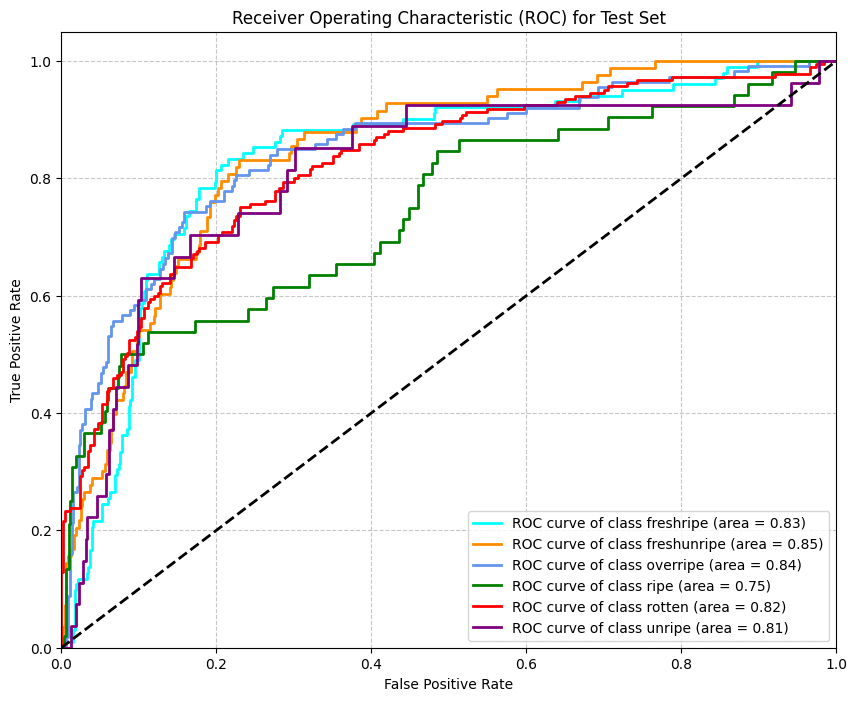

In [ ]:
# Get predicted probabilities for the test set
y_prob_test = log_reg.predict_proba(X_test)

# Binarize the true labels for ROC curve calculation
y_test_onehot = pd.get_dummies(y_test_encoded).values

# Compute ROC curve and AUC for each class on the test set
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_onehot[:, i], y_prob_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves for the test set
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(label_encoder.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Test Set')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Random Forest Classifier

Following the logistic regression, we will now implement a Random Forest Classifier. Random Forests are ensemble learning methods that can often provide better accuracy and are generally considered more interpretable than complex deep learning models, making them a good choice for comparison. We will use the same color features extracted previously.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest model
# Using default parameters for now, can be tuned later if needed
# `random_state` for reproducibility
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train_encoded)

print("\nRandom Forest Classifier Model Trained.")


Random Forest Classifier Model Trained.


### Random Forest Model Evaluation

Random Forest Validation Accuracy: 0.8308

Random Forest Validation Classification Report:
              precision    recall  f1-score   support

   freshripe       0.82      0.81      0.81       207
 freshunripe       0.82      0.90      0.86       136
    overripe       0.85      0.86      0.86       229
        ripe       0.79      0.73      0.76       132
      rotten       0.85      0.87      0.86       388
      unripe       0.69      0.35      0.47        31

    accuracy                           0.83      1123
   macro avg       0.80      0.75      0.77      1123
weighted avg       0.83      0.83      0.83      1123



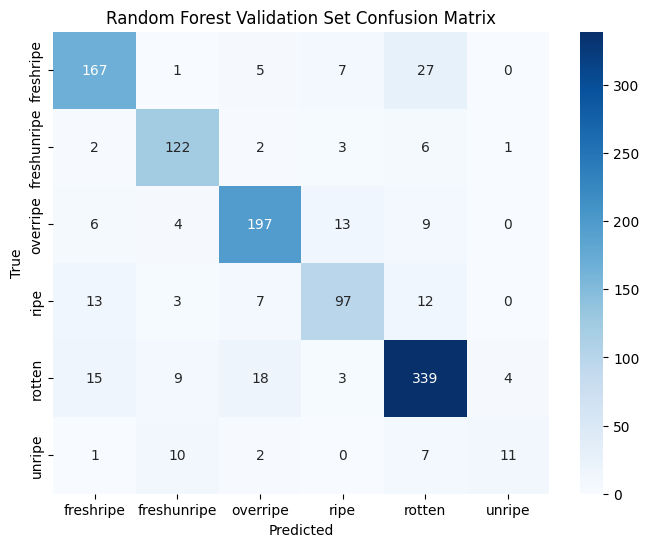


Random Forest Test Accuracy: 0.8185

Random Forest Test Classification Report:
              precision    recall  f1-score   support

   freshripe       0.81      0.81      0.81       102
 freshunripe       0.86      0.84      0.85        83
    overripe       0.83      0.88      0.86       113
        ripe       0.73      0.67      0.70        52
      rotten       0.82      0.86      0.84       185
      unripe       0.86      0.44      0.59        27

    accuracy                           0.82       562
   macro avg       0.82      0.75      0.77       562
weighted avg       0.82      0.82      0.81       562



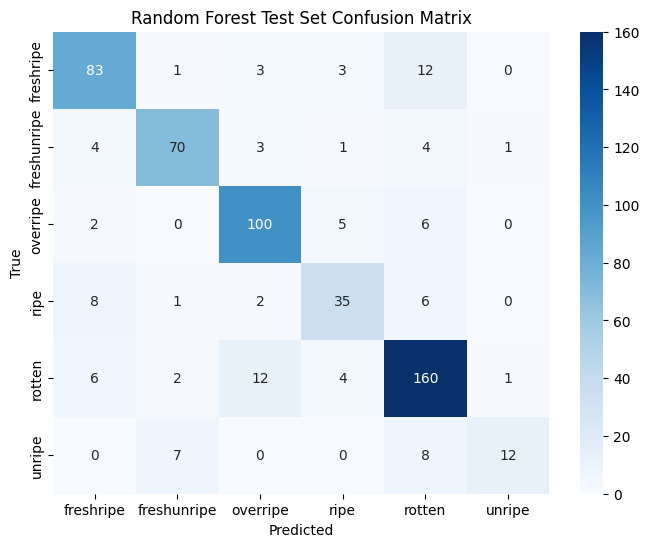

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Evaluate the Random Forest model on the validation set
y_pred_valid_rf = rf_classifier.predict(X_valid)
accuracy_valid_rf = accuracy_score(y_valid_encoded, y_pred_valid_rf)
print(f"Random Forest Validation Accuracy: {accuracy_valid_rf:.4f}")

print("\nRandom Forest Validation Classification Report:")
print(classification_report(y_valid_encoded, y_pred_valid_rf, target_names=label_encoder.classes_))

# Confusion Matrix for Validation Set (Random Forest)
cm_valid_rf = confusion_matrix(y_valid_encoded, y_pred_valid_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_valid_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Random Forest Validation Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Evaluate the Random Forest model on the test set
y_pred_test_rf = rf_classifier.predict(X_test)
accuracy_test_rf = accuracy_score(y_test_encoded, y_pred_test_rf)
print(f"\nRandom Forest Test Accuracy: {accuracy_test_rf:.4f}")

print("\nRandom Forest Test Classification Report:")
print(classification_report(y_test_encoded, y_pred_test_rf, target_names=label_encoder.classes_))

# Confusion Matrix for Test Set (Random Forest)
cm_test_rf = confusion_matrix(y_test_encoded, y_pred_test_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Random Forest Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Random Forest AUC-ROC Curves

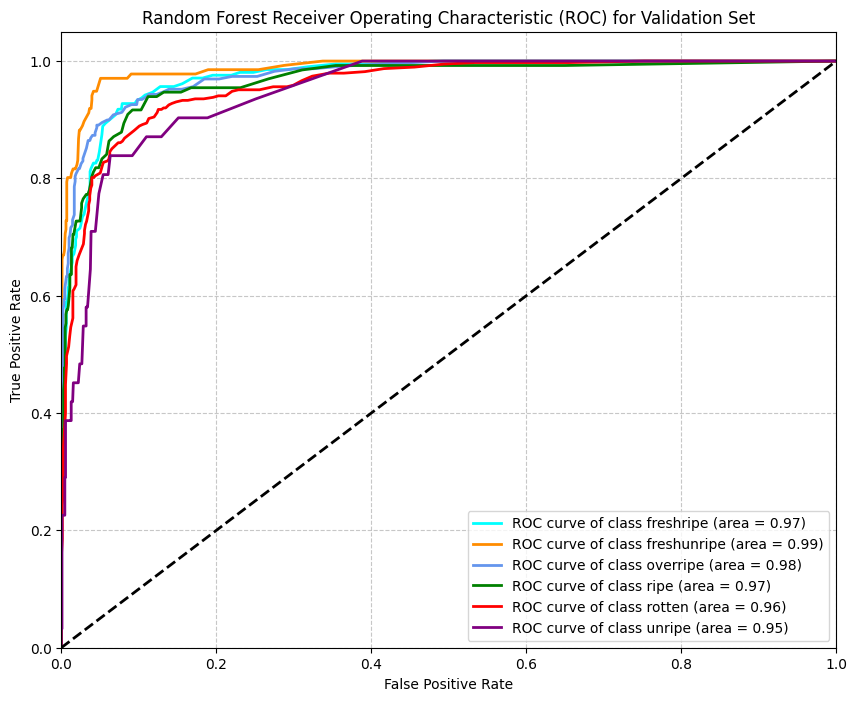

In [ ]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Get predicted probabilities for the validation set (Random Forest)
y_prob_valid_rf = rf_classifier.predict_proba(X_valid)

# Binarize the true labels for ROC curve calculation
# n_classes is already defined from logistic regression setup
# y_valid_onehot is already available from logistic regression setup

# Compute ROC curve and AUC for each class on the validation set
fpr_rf_valid = dict()
tpr_rf_valid = dict()
roc_auc_rf_valid = dict()
for i in range(n_classes):
    fpr_rf_valid[i], tpr_rf_valid[i], _ = roc_curve(y_valid_onehot[:, i], y_prob_valid_rf[:, i])
    roc_auc_rf_valid[i] = auc(fpr_rf_valid[i], tpr_rf_valid[i])

# Plot all ROC curves for the validation set
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_rf_valid[i], tpr_rf_valid[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(label_encoder.classes_[i], roc_auc_rf_valid[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic (ROC) for Validation Set')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

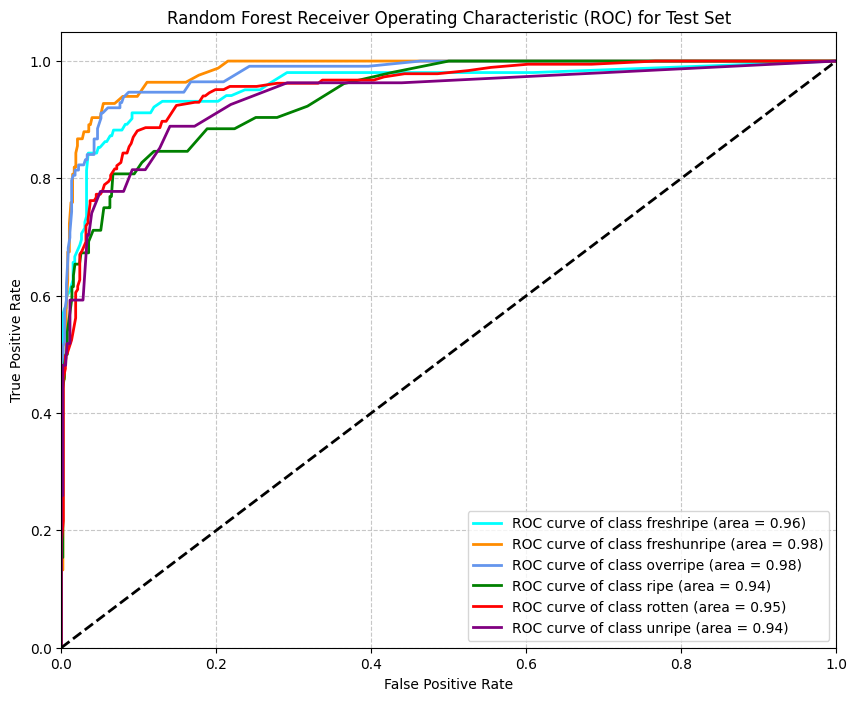

In [ ]:
# Get predicted probabilities for the test set (Random Forest)
y_prob_test_rf = rf_classifier.predict_proba(X_test)

# Binarize the true labels for ROC curve calculation
# y_test_onehot is already available from logistic regression setup

# Compute ROC curve and AUC for each class on the test set
fpr_rf_test = dict()
tpr_rf_test = dict()
roc_auc_rf_test = dict()
for i in range(n_classes):
    fpr_rf_test[i], tpr_rf_test[i], _ = roc_curve(y_test_onehot[:, i], y_prob_test_rf[:, i])
    roc_auc_rf_test[i] = auc(fpr_rf_test[i], tpr_rf_test[i])

# Plot all ROC curves for the test set
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_rf_test[i], tpr_rf_test[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(label_encoder.classes_[i], roc_auc_rf_test[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic (ROC) for Test Set')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Banana Ripeness Classification Using Transfer Learning

## Project Objective

The objective of this project is to build an image classification system able to identify different banana ripeness stages from photographs using a pretrained model (MobileNetV2).


## Dataset and Class Labels

The dataset is divided into three independent subsets:

- The training set is used to update the trainable model parameters.
- The validation set is used during model development to monitor generalisation performance and detect possible overfitting.
- The test set is reserved for the final evaluation of the trained model.

The dataset consists of banana images organised into folders according to their ripeness category. The dataset contains six classes:

- `freshripe`
- `freshunripe`
- `overripe`
- `ripe`
- `rotten`
- `unripe`

The labels are inferred from the folder names. For example, an image stored in the `rotten` folder receives the `rotten` class label.TensorFlow converts the class names into integer labels. The mapping used by the dataset is displayed below.

The original images have different resolutions and orientations. Neural networks require inputs with a consistent shape, so all images are resized to 224 × 224 pixels when they are loaded.

Images are loaded in RGB format, resulting in three colour channels. The images are processed in batches of 32. A batch therefore has the shape `(32, 224, 224, 3)`, where:

- 32 is the number of images in the batch;
- 224 × 224 is the resized image resolution;
- 3 represents the RGB channels.

The training dataset is shuffled to avoid presenting the model with images in a fixed class order. Validation and test datasets are not shuffled, which makes it easier to align predictions with the corresponding true labels during evaluation.



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

img_height = 224
img_width = 224
batch_size = 32

dataset_path = Path("./Banana_Ripeness_Dataset")

seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = dataset_path / "train",
    labels = "inferred", # labels from subfolders
    label_mode = "int", # classes are integer
    color_mode = "rgb",
    batch_size = batch_size,
    image_size = (img_height, img_width),
    shuffle = True, # randomize train_ds images
    seed = seed
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    directory = dataset_path / "valid",
    labels = "inferred",
    label_mode = "int",
    color_mode = "rgb",
    batch_size = batch_size,
    image_size = (img_height, img_width),
    shuffle = False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    directory = dataset_path / "test",
    labels = "inferred",
    label_mode = "int",
    color_mode = "rgb",
    batch_size = batch_size,
    image_size = (img_height, img_width),
    shuffle = False
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 3931 files belonging to 6 classes.
Found 1123 files belonging to 6 classes.
Found 562 files belonging to 6 classes.


In [ ]:
import pandas as pd

# Get the class names from the training dataset
class_names = train_ds.class_names

for label, class_name in enumerate(class_names):
    print(f"Label {label} → {class_name}")

Label 0 → freshripe
Label 1 → freshunripe
Label 2 → overripe
Label 3 → ripe
Label 4 → rotten
Label 5 → unripe


The same class order is checked across the training, validation, and test datasets to ensure that the numeric labels have the same meaning in all three splits.

In [ ]:
print("Training classes:  ", train_ds.class_names)
print("Validation classes:", valid_ds.class_names)
print("Test classes:      ", test_ds.class_names)

assert train_ds.class_names == valid_ds.class_names == test_ds.class_names
print("The label mapping is consistent across all dataset splits.")

Training classes:   ['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']
Validation classes: ['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']
Test classes:       ['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']
The label mapping is consistent across all dataset splits.


## Visual Verification of the Loaded Dataset

The following visualisations show:

- images after they have been loaded and resized by TensorFlow. The class name is displayed above each image to verify that the images and labels are correctly aligned.

- comparison between original and preprocessed image (RGB conversion + resizing)



Batch labels:
[2 4 2 4 0 5 2 2 4 5 3 2 1 1 4 3 0 1 1 3 2 4 0 4 4 1 1 3 2 3 4 2]





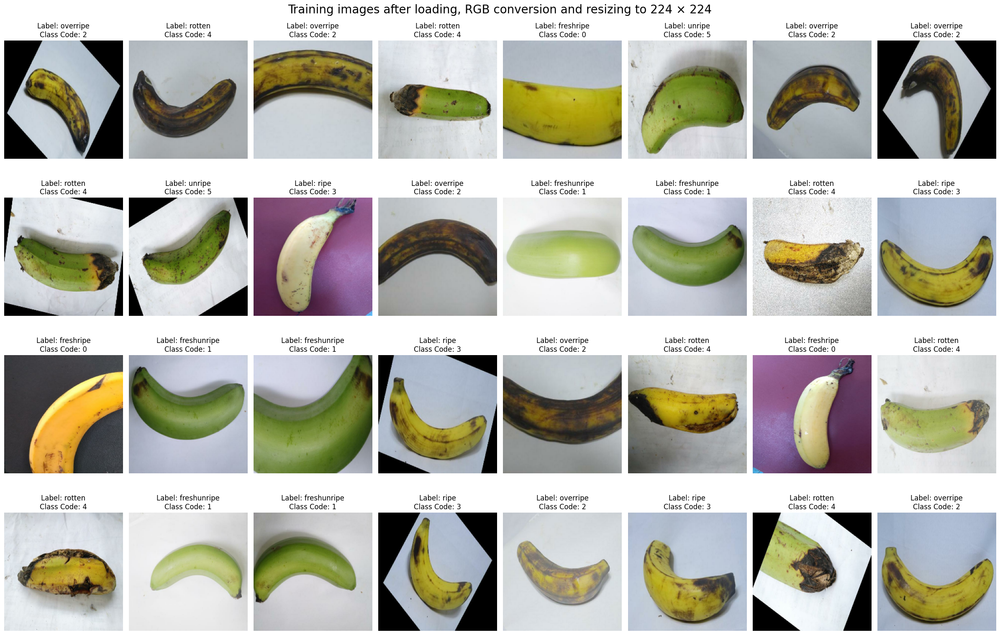

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

print("\nBatch labels:")
print(labels[:32].numpy())
print("\n\n")

plt.figure(figsize=(24, 16))

for i in range(32):
    ax = plt.subplot(4, 8, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label_index = int(labels[i].numpy())
    plt.title(
        f"Label: {class_names[label_index]}\n"
        f"Class Code: {label_index}"
    )
    plt.axis("off")

plt.suptitle(
    "Training images after loading, RGB conversion and resizing to 224 × 224",
    y=0.98,
    fontsize=20
)

plt.tight_layout()
plt.show()

Original image shape: (480, 640, 3)
RGB converted image shape: (480, 640, 3)
Preprocessed image shape: (224, 224, 3)


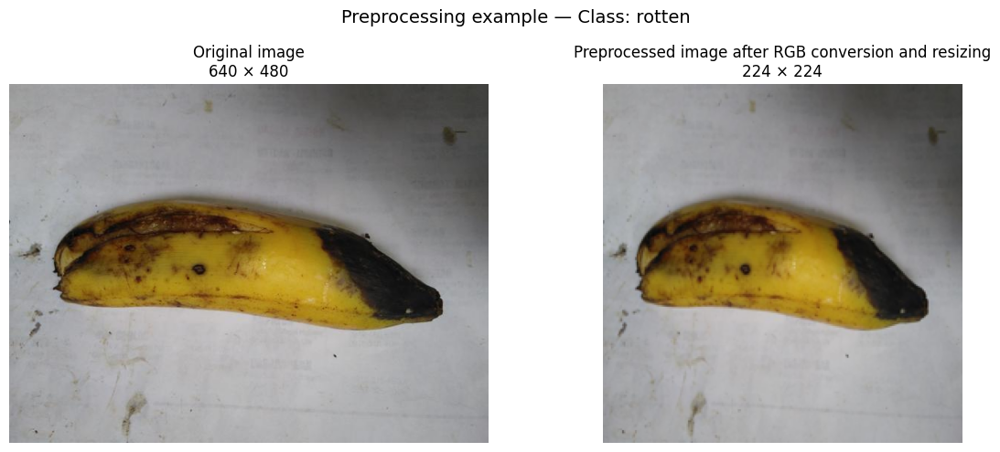

In [ ]:
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

image_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

original_image_path = next(path for path in (dataset_path / "train").rglob("*")if path.suffix.lower() in image_extensions)

original_image = Image.open(original_image_path)

RGB_coverted_image = original_image.convert("RGB")

original_image_array = np.array(original_image)
RGB_coverted_image_array = np.array(RGB_coverted_image)

preprocessed_image = RGB_coverted_image.resize(
    (img_width, img_height)
)

preprocessed_image_array = np.array(preprocessed_image)

print("Original image shape:", original_image_array.shape)
print("RGB converted image shape:", RGB_coverted_image_array.shape)
print("Preprocessed image shape:", preprocessed_image_array.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_image)
axes[0].set_title(
    f"Original image\n{original_image.width} × {original_image.height}"
)
axes[0].axis("off")

axes[1].imshow(preprocessed_image)
axes[1].set_title(
    f"Preprocessed image after RGB conversion and resizing\n{img_width} × {img_height}"
)
axes[1].axis("off")

plt.suptitle(
    f"Preprocessing example — Class: {original_image_path.parent.name}",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Model Architecture

We use transfer learning with MobileNetV2, a convolutional neural network pre-trained on ImageNet.

MobileNetV2 was selected for three main reasons:

1. It has already learned general visual features such as edges, colours, shapes, and textures.
2. It is relatively lightweight and computationally efficient.
3. It is suitable for a dataset of moderate size and can be trained in Google Colab without requiring a very complex architecture.

Instead of training the entire network from scratch, we use MobileNetV2 as a fixed feature extractor and train a new classification head for the six banana-ripeness classes.
The MobileNetV2 base is loaded without its original ImageNet classification head. The original head is removed because it predicts ImageNet categories, whereas this project requires six banana-ripeness categories.

The base model is frozen during the first training stage. Therefore, its pre-trained weights remain unchanged and only the newly added classification layer is trained.


The final model consists of the following components:

1. An input layer receiving RGB images of size 224 × 224.
2. MobileNetV2, used as a frozen feature extractor.
3. GlobalAveragePooling2D, which converts the convolutional feature maps into a compact feature vector.
4. Dropout, used to reduce overfitting in the new classification head.
5. A Dense output layer with six neurons and a softmax activation function.

The softmax layer produces one probability for each ripeness class. The predicted class is the class with the highest probability.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(
    shape=(img_height, img_width, 3),
    name="input_image"
)

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.20,
    name="dropout"
)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="ripeness_prediction"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="banana_ripeness_mobilenetv2"
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "banana_ripeness_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ripeness_prediction (Dense)     │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

The model contains 2,265,670 parameters in total. Most parameters belong to the pre-trained MobileNetV2 base and are non-trainable. Only 7,686 parameters in the final Dense layer are trainable during the initial transfer-learning stage.

The output shape is `(None, 6)`, meaning that the model produces six class probabilities for each input image.

## Model Compilation

The model is compiled using the Adam optimiser, sparse categorical cross-entropy loss, and accuracy as the main metric.

Sparse categorical cross-entropy is appropriate because the labels are represented as integer class identifiers. The Adam optimiser is used because it adapts the size of the parameter updates during training and provides a strong baseline for this classification problem.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Inspection of intermediate outputs

The following section is included for better understanding. It is not required for the final classifier, but it helps illustrate how the image representation changes as it passes through the network.

The input image first has the shape `(224, 224, 3)`. MobileNetV2 transforms it into convolutional feature maps. GlobalAveragePooling2D then converts these feature maps into a compact feature vector, which is passed to the classification head.

In [ ]:
sample_images, sample_labels = next(iter(train_ds))

print("Input batch shape:", sample_images.shape)

Input batch shape: (32, 224, 224, 3)


In [ ]:
for layer in model.layers:
    print(layer.name, layer.output.shape)

input_image (None, 224, 224, 3)
mobilenetv2_1.00_224 (None, 7, 7, 1280)
global_average_pooling (None, 1280)
dropout (None, 1280)
ripeness_prediction (None, 6)


### MobileNetV2 preprocessing

The input images are initially represented with RGB pixel values in the approximate range [0, 255]. MobileNetV2 preprocessing rescales these values to the range [-1, 1] using the transformation:

x' = x / 127.5 - 1

The image shape remains unchanged. Therefore, a batch with shape `(32, 224, 224, 3)` keeps the same shape after preprocessing; only the numerical pixel range changes.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

sample_images, sample_labels = next(iter(train_ds))

print("Input batch shape:", sample_images.shape)
print("Input pixel range:")
print(
    float(tf.reduce_min(sample_images).numpy()),
    "to",
    float(tf.reduce_max(sample_images).numpy())
)

Input batch shape: (32, 224, 224, 3)
Input pixel range:
0.0 to 255.0


In [ ]:
preprocessed_images = tf.keras.applications.mobilenet_v2.preprocess_input(
    tf.cast(sample_images, tf.float32)
)

print("Preprocessed batch shape:", preprocessed_images.shape)
print("Preprocessed pixel range:")
print(
    float(tf.reduce_min(preprocessed_images).numpy()),
    "to",
    float(tf.reduce_max(preprocessed_images).numpy())
)

Preprocessed batch shape: (32, 224, 224, 3)
Preprocessed pixel range:
-1.0 to 1.0


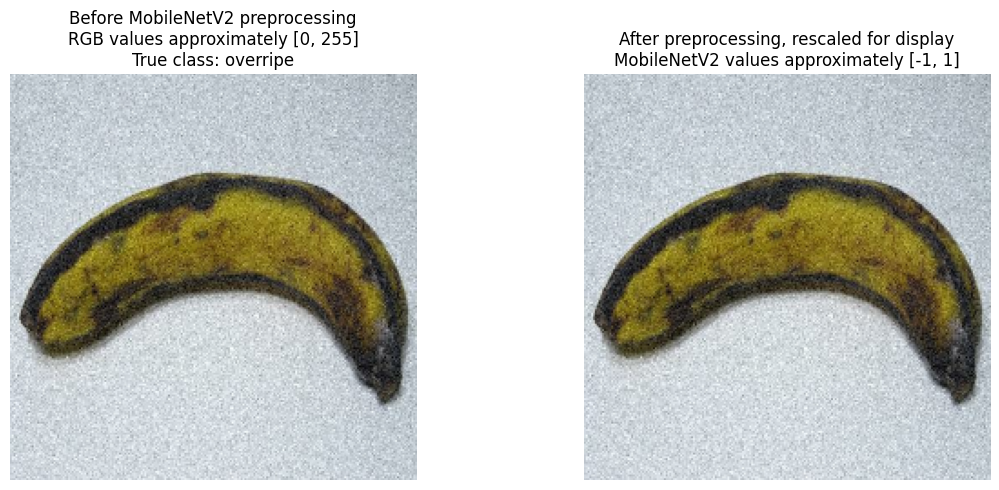

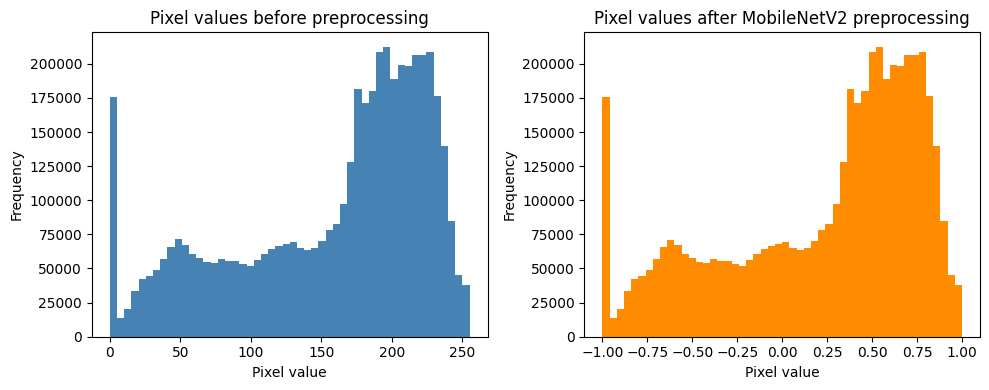

In [ ]:
image_index = 0

original_image = sample_images[image_index].numpy().astype("uint8")

normalized_image = preprocessed_images[image_index]

normalized_for_display = (
    (normalized_image + 1.0) * 127.5
)

normalized_for_display = tf.clip_by_value(
    normalized_for_display,
    0,
    255
).numpy().astype("uint8")

true_label = int(sample_labels[image_index].numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_image)
axes[0].set_title(
    f"Before MobileNetV2 preprocessing\n"
    f"RGB values approximately [0, 255]\n"
    f"True class: {class_names[true_label]}"
)
axes[0].axis("off")

axes[1].imshow(normalized_for_display)
axes[1].set_title(
    "After preprocessing, rescaled for display\n"
    f"MobileNetV2 values approximately [-1, 1]"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(
    sample_images.numpy().flatten(),
    bins=50,
    color="steelblue"
)
plt.title("Pixel values before preprocessing")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(
    preprocessed_images.numpy().flatten(),
    bins=50,
    color="darkorange"
)
plt.title("Pixel values after MobileNetV2 preprocessing")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Opzionale feature map da capire

## Training Control

Two callbacks are used to control the training process.

EarlyStopping monitors the validation loss and stops training when the model does not improve for several consecutive epochs. The best weights are restored after training.

ReduceLROnPlateau reduces the learning rate when the validation loss reaches a plateau. This allows the model to make smaller updates when the optimisation process becomes slower.

These callbacks help reduce unnecessary training and limit the risk of overfitting.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

## Model Training

The model is trained using the training dataset and evaluated after each epoch on the validation dataset.

The maximum number of epochs is set to 20. This is an upper limit rather than a requirement: EarlyStopping may stop the training earlier if the validation loss no longer improves.

In [ ]:
epochs = 20

history = model.fit(
    train_ds,
    validation_data = valid_ds,
    epochs = epochs,
    callbacks = [early_stopping, reduce_lr]
)

Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.7962 - loss: 0.6135 - val_accuracy: 0.9190 - val_loss: 0.3013 - learning_rate: 0.0010
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9222 - loss: 0.2761 - val_accuracy: 0.9377 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9354 - loss: 0.2185 - val_accuracy: 0.9412 - val_loss: 0.2055 - learning_rate: 0.0010
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9461 - loss: 0.1848 - val_accuracy: 0.9501 - val_loss: 0.1806 - learning_rate: 0.0010
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9522 - loss: 0.1619 - val_accuracy: 0.9528 - val_loss: 0.1675 - learning_rate: 0.0010
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9532 - loss: 0.1483 - val_accuracy: 0.9510 - val_loss: 0.1612 - learning_rate: 0.0010
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9596 - loss: 0.

In [ ]:
last_epoch = len(history.history["loss"]) - 1

print("Epoche completate:", len(history.history["loss"]))
print("Training loss:", round(history.history["loss"][last_epoch], 4))
print("Training accuracy:", round(history.history["accuracy"][last_epoch], 4))
print("Validation loss:", round(history.history["val_loss"][last_epoch], 4))
print("Validation accuracy:", round(history.history["val_accuracy"][last_epoch], 4))

Epoche completate: 20
Training loss: 0.0683
Training accuracy: 0.9812
Validation loss: 0.1225
Validation accuracy: 0.959


The model achieved a training accuracy of approximately 97.48% and a validation accuracy of approximately 95.81% at the final recorded epoch. The training and validation performances are relatively close, suggesting that the model does not show severe overfitting.

The best validation loss was achieved before the final epoch, so the model restores the weights from the best validation epoch.

## Training Curves

The following plots compare training and validation accuracy and loss over the training epochs.

The accuracy plot shows how classification performance changes over time. The loss plot shows the prediction error. A large and persistent gap between training and validation performance could indicate overfitting, whereas close curves suggest better generalisation.

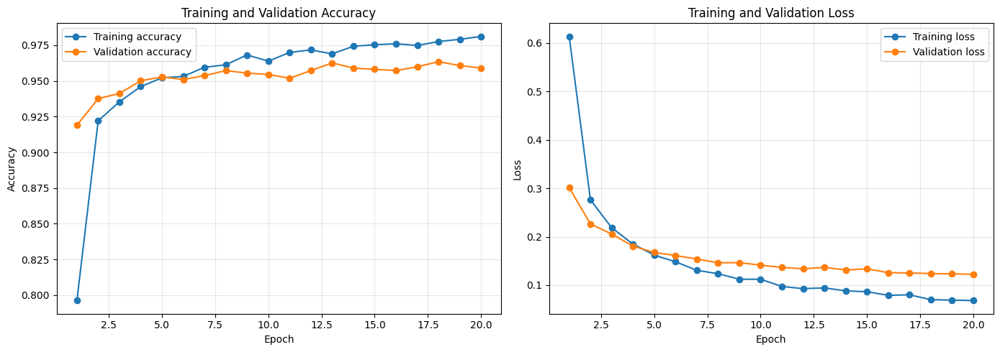

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    history.history["accuracy"],
    marker="o",
    label="Training accuracy"
)
plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    history.history["loss"],
    marker="o",
    label="Training loss"
)
plt.plot(
    epochs_range,
    history.history["val_loss"],
    marker="o",
    label="Validation loss"
)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Final Test-Set Evaluation

The test set is used only after training has been completed. It contains images that were not used to update model weights or monitor the training process.

The evaluation includes accuracy, precision, recall, F1-score, and a confusion matrix. These additional metrics are important because accuracy alone may hide weak performance in individual classes.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 908ms/step - accuracy: 0.9555 - loss: 0.1230

Test loss: 0.1230
Test accuracy: 0.9555
Test accuracy: 95.55%


In [ ]:
import numpy as np

y_true = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

probabilities = model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(probabilities, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 955ms/step


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
freshripe,0.934579,0.980392,0.956938,102.000000
freshunripe,1.000000,1.000000,1.000000,83.000000
overripe,0.990741,0.946903,0.968326,113.000000
ripe,0.860000,0.826923,0.843137,52.000000
rotten,0.957447,0.972973,0.965147,185.000000
unripe,0.923077,0.888889,0.905660,27.000000
accuracy,0.955516,0.955516,0.955516,0.955516
macro avg,0.944307,0.936013,0.939868,562.000000
weighted avg,0.955608,0.955516,0.955297,562.000000


The model achieved a test accuracy of 94.84% on 562 test images. The macro-average F1-score was approximately 93.14%, while the weighted-average F1-score was approximately 94.86%.

The strongest performance was obtained for `freshunripe`, with an F1-score of 1.00, and `rotten`, with an F1-score of approximately 0.96. The weakest class was `ripe`, with an F1-score of approximately 0.81. This suggests that intermediate ripeness stages are more difficult to distinguish visually than clearly unripe or rotten bananas.

## Confusion Matrix

The confusion matrix compares the true class labels with the predicted labels.

Rows represent the true classes, while columns represent the predicted classes. Values on the diagonal correspond to correct predictions. Off-diagonal values represent classification errors.

The largest confusion involves neighbouring ripeness stages, especially `ripe` and `freshripe`. This is plausible because these classes may have similar peel colours and visual characteristics. `Overripe` is also sometimes confused with `ripe` or `rotten`, reflecting its intermediate position between these categories.

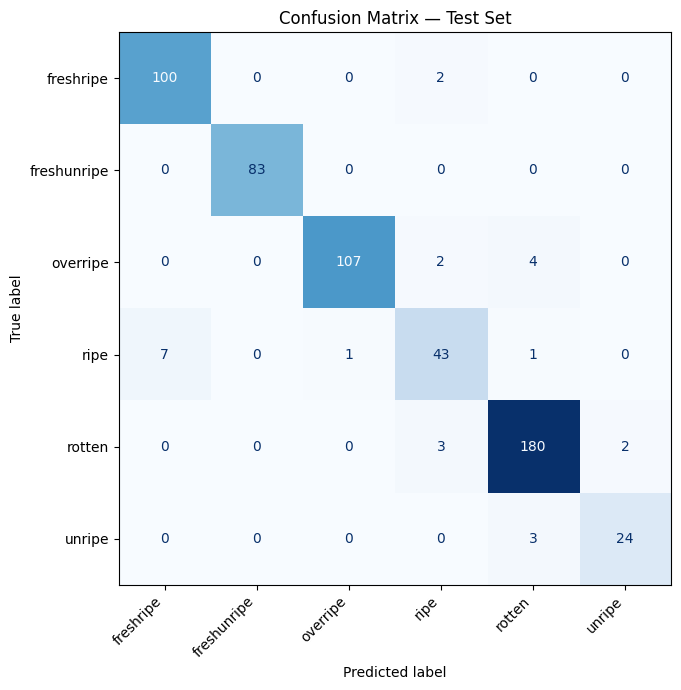

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(len(class_names))
)

fig, ax = plt.subplots(figsize=(9, 7))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display_cm.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix — Test Set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Predictions on External Images

To test whether the model can generalise beyond the original dataset, external banana images are uploaded and classified.

Each image is converted to RGB, resized to 224 × 224 pixels, placed into a batch with one image, and passed to the trained model. The model returns six probabilities, one for each ripeness class. The final prediction is the class with the highest probability.

External images are useful for identifying possible limitations related to image quality, lighting, background, camera angle, watermarks, and differences between the training dataset and real-world photographs.

In [ ]:
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def predict_image(
    image_path,
    model,
    class_names,
    img_height=224,
    img_width=224
):
    image_path = str(image_path)

    image = Image.open(image_path).convert("RGB")

    resized_image = image.resize(
        (img_width, img_height)
    )

    image_array = np.array(
        resized_image,
        dtype=np.float32
    )

    input_batch = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        input_batch,
        verbose=0
    )[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_class = class_names[predicted_index]
    confidence = float(probabilities[predicted_index])

    probability_table = pd.DataFrame({
        "class": class_names,
        "probability": probabilities,
        "percentage": probabilities * 100
    }).sort_values(
        by="probability",
        ascending=False
    ).reset_index(drop=True)

    plt.figure(figsize=(6, 5))
    plt.imshow(image)
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2%}"
    )
    plt.axis("off")
    plt.show()

    display(
        probability_table.style.format({
            "probability": "{:.4f}",
            "percentage": "{:.2f}%"
        })
    )

    plt.figure(figsize=(9, 5))
    plt.bar(
        probability_table["class"],
        probability_table["percentage"],
        color="darkorange"
    )

    plt.title(f"Predicted probabilities — {image_path.split('/')[-1]}")
    plt.xlabel("Ripeness class")
    plt.ylabel("Probability (%)")
    plt.ylim(0, 100)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "image_path": image_path,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "probabilities": probabilities,
        "probability_table": probability_table
    }

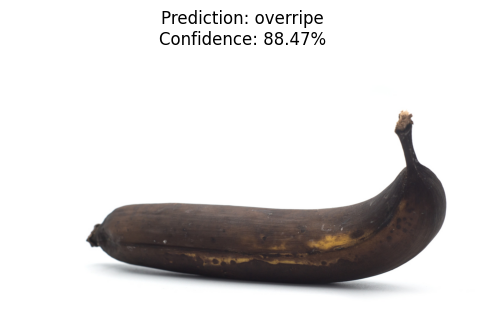

,class,probability,percentage
0,overripe,0.8847,88.47%
1,rotten,0.1034,10.34%
2,freshripe,0.0100,1.00%
3,freshunripe,0.0012,0.12%
4,ripe,0.0007,0.07%
5,unripe,0.0000,0.00%


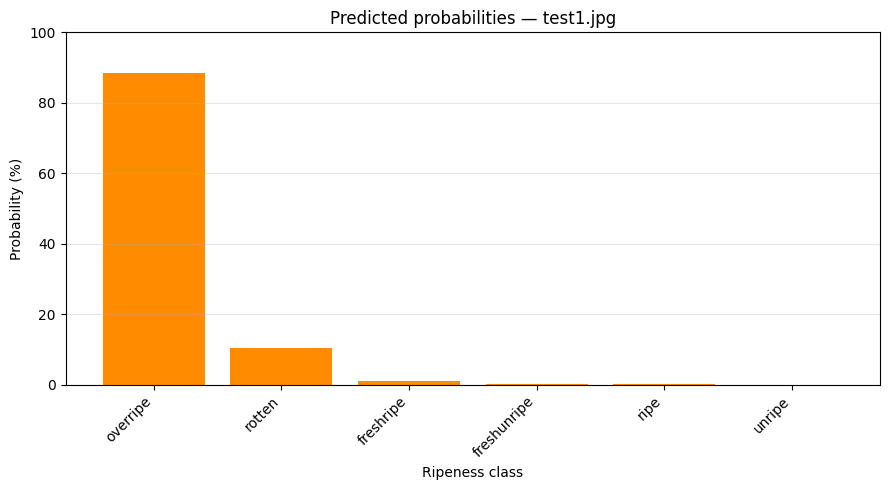

In [ ]:
image1_path = '/content/drive/MyDrive/Group Assignment - A26_I_DTS_DL_03/test1.jpg'

result_1 = predict_image(
    image_path = image1_path,
    model=model,
    class_names=class_names,
    img_height=img_height,
    img_width=img_width
)

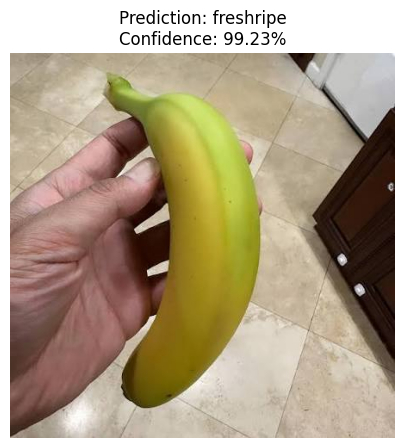

,class,probability,percentage
0,freshripe,0.9923,99.23%
1,rotten,0.0071,0.71%
2,ripe,0.0004,0.04%
3,freshunripe,0.0001,0.01%
4,overripe,0.0000,0.00%
5,unripe,0.0000,0.00%


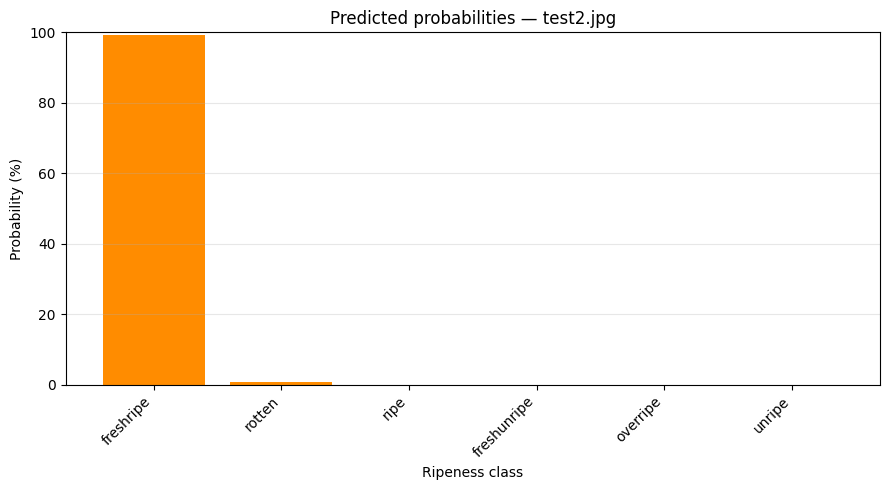

In [ ]:
image2_path = '/content/drive/MyDrive/Group Assignment - A26_I_DTS_DL_03/test2.jpg'

result_1 = predict_image(
    image_path = image2_path,
    model=model,
    class_names=class_names,
    img_height=img_height,
    img_width=img_width
)

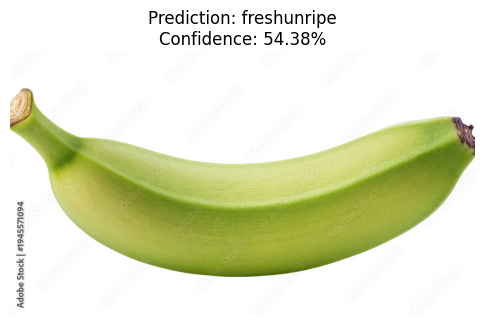

,class,probability,percentage
0,freshunripe,0.5438,54.38%
1,freshripe,0.4366,43.66%
2,ripe,0.0191,1.91%
3,rotten,0.0003,0.03%
4,unripe,0.0001,0.01%
5,overripe,0.0001,0.01%


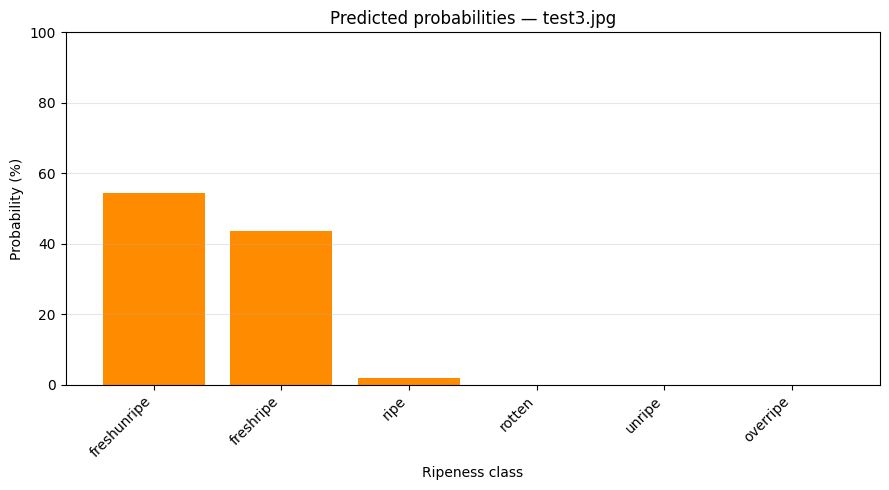

In [ ]:
image3_path = '/content/drive/MyDrive/Group Assignment - A26_I_DTS_DL_03/test3.jpg'

result_1 = predict_image(
    image_path = image3_path,
    model=model,
    class_names=class_names,
    img_height=img_height,
    img_width=img_width
)

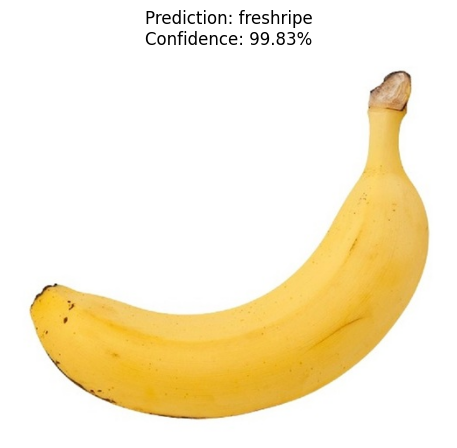

,class,probability,percentage
0,freshripe,0.9983,99.83%
1,ripe,0.0014,0.14%
2,rotten,0.0002,0.02%
3,overripe,0.0001,0.01%
4,freshunripe,0.0000,0.00%
5,unripe,0.0000,0.00%


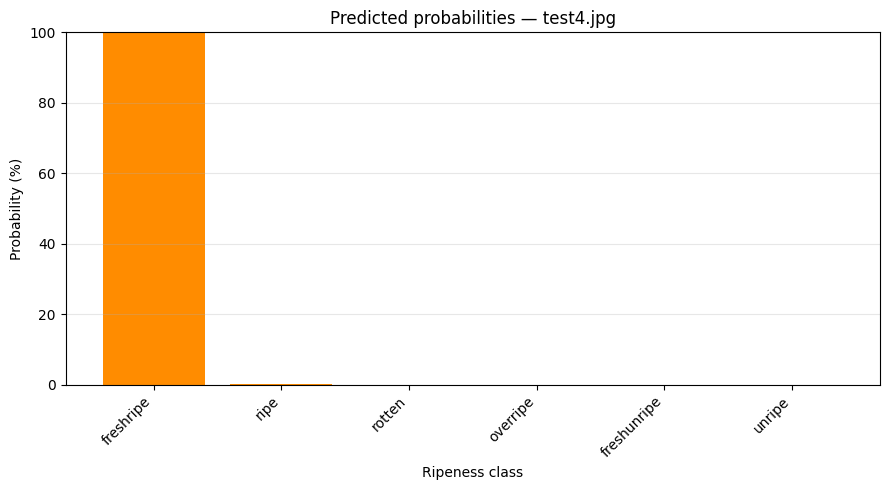

In [ ]:
image4_path = '/content/drive/MyDrive/Group Assignment - A26_I_DTS_DL_03/test4.jpg'

result_1 = predict_image(
    image_path = image4_path,
    model=model,
    class_names=class_names,
    img_height=img_height,
    img_width=img_width
)

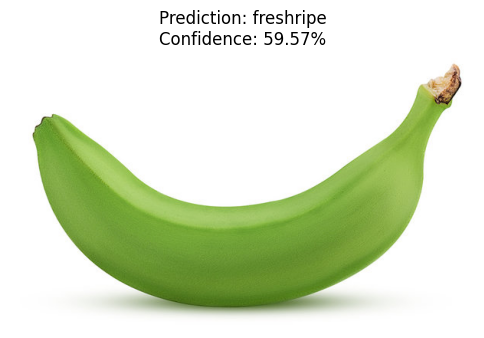

,class,probability,percentage
0,freshripe,0.5957,59.57%
1,freshunripe,0.4041,40.41%
2,overripe,0.0001,0.01%
3,ripe,0.0000,0.00%
4,unripe,0.0000,0.00%
5,rotten,0.0000,0.00%


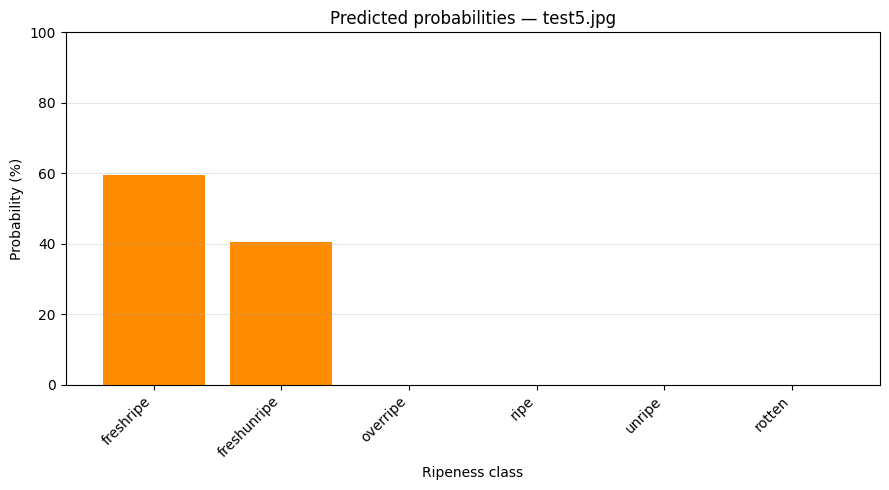

In [ ]:
image5_path = '/content/drive/MyDrive/Group Assignment - A26_I_DTS_DL_03/test5.jpg'

result_1 = predict_image(
    image_path = image5_path,
    model=model,
    class_names=class_names,
    img_height=img_height,
    img_width=img_width
)